<div class="alert alert-block alert-success">
<h1> DATA MINING - PROJECT </h1>
<h2> Group 19 </h2>
<h3> 20225/2026 </h3>

Student Name - António Parafita <br>
Student id - 20250363 <br>

Student Name - Diogo Montenegro <br>
Student id - 20250491 <br>

Student Name - Francisco <br>
Student id - 20250482 <br>

## **Index**<br>



<a class="anchor" id="1st-bullet">    </a>
# 1. Imports

<a class="anchor" id="2st-bullet">    </a>
## 1.1 Import libraries

In [622]:
import sqlite3
import os
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import ceil

from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder, OrdinalEncoder
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.impute import KNNImputer
from itertools import product
from sklearn.neighbors import NearestNeighbors
#maps
import folium
from folium.plugins import MarkerCluster
from folium.plugins import HeatMap
from IPython.display import IFrame

from ydata_profiling import ProfileReport

# for better resolution plots
%config InlineBackend.figure_format = 'retina' # optionally, you can change 'svg' to 'retina'

# Setting seaborn style
sns.set_style("ticks")

## Functions

In [623]:
def detect_outliers_iqr(data, threshold=0.01):
    """
    Detects outliers in numerical columns using the Interquartile Range (IQR) method
    and optionally reports columns where the percentage of outliers exceeds a threshold.
    A boxplot highlighting the outliers is also generated for each column.

    Parameters:
        data (DataFrame): 
            The input dataset containing numerical variables.
    """
    outlier_summary = []
    for col in data.select_dtypes(include=['float64', 'int64']).columns:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        # Identify outliers
        outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)][col]
        n_outliers = len(outliers)
        pct_outliers = 100 * n_outliers / len(data)
        # Print summary
        print(f"Column: {col} - Number of Outliers: {n_outliers}")
        print(f"Column: {col} - % of Outliers: {pct_outliers:.2f}%\n")
        # Add to list if exceeds threshold
        if pct_outliers > threshold * 100:
            outlier_summary.append((col, n_outliers, pct_outliers))
        # Plot boxplot
        plt.figure(figsize=(8, 5))
        sns.boxplot(x=data[col], color='orange')
        sns.stripplot(x=outliers, color='red', size=4, label='Outliers')
        plt.title(f'Boxplot with Outliers for {col}', fontsize=14)
        plt.legend()
        plt.show()
    return pd.DataFrame(outlier_summary, columns=['Column', 'Num_Outliers', 'Pct_Outliers'])

<a class="anchor" id="3st-bullet">    </a>
## 1.2 Import Data

In [624]:
customers = pd.read_csv('data/DM_AIAI_CustomerDB.csv', index_col = 0)
flights = pd.read_csv('data/DM_AIAI_FlightsDB.csv')

In [625]:
df_c = customers.copy()

In [626]:
df_f = flights.copy()

In [627]:
df_f.isna().sum()

Loyalty#                    0
Year                        0
Month                       0
YearMonthDate               0
NumFlights                  0
NumFlightsWithCompanions    0
DistanceKM                  0
PointsAccumulated           0
PointsRedeemed              0
DollarCostPointsRedeemed    0
dtype: int64

## 2 Data Preprocessing


Before starting, we'll make the changes proposed on the EDA notebook.

In [628]:
df_c['Country'].unique()

array(['Canada'], dtype=object)

Since all the customers are from Canada, we are going to drop this column since this does not give us any relevant information.

In [629]:
df_c = df_c.drop('Country', axis=1)

We also saw that "Location Code" seems random.

In [630]:
df_c.loc[df_c['Postal code'] == 'M2M 7K8', ['City','Postal code','Location Code']]

,City,Postal code,Location Code
14,Toronto,M2M 7K8,Rural
102,Toronto,M2M 7K8,Suburban
143,Toronto,M2M 7K8,Urban
157,Toronto,M2M 7K8,Rural
206,Toronto,M2M 7K8,Suburban
...,...,...,...
16776,Toronto,M2M 7K8,Urban
16795,Toronto,M2M 7K8,Urban
16801,Toronto,M2M 7K8,Suburban
16845,Toronto,M2M 7K8,Urban


As we can observe, people from the same area ("Postal Code") have different "Location Code".

In [631]:
df_c = df_c.drop('Location Code', axis=1)

Finnaly, the names of the customers are also meaningless, since we already have the loyalty number as an identifier, so we are also going to drop it.

In [632]:
df_c = df_c.drop('First Name', axis=1)
df_c = df_c.drop('Last Name', axis=1)
df_c = df_c.drop('Customer Name', axis=1)

In [633]:
df_c

,Loyalty#,Province or State,City,Latitude,Longitude,Postal code,Gender,Education,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType
0,480934,Ontario,Toronto,43.653225,-79.383186,M2Z 4K1,female,Bachelor,70146.0,Married,Star,2/15/2019,NaN,3839.14,Standard
1,549612,Alberta,Edmonton,53.544388,-113.490930,T3G 6Y6,male,College,0.0,Divorced,Star,3/9/2019,NaN,3839.61,Standard
2,429460,British Columbia,Vancouver,49.282730,-123.120740,V6E 3D9,male,College,0.0,Single,Star,7/14/2017,1/8/2021,3839.75,Standard
3,608370,Ontario,Toronto,43.653225,-79.383186,P1W 1K4,male,College,0.0,Single,Star,2/17/2016,NaN,3839.75,Standard
4,530508,Quebec,Hull,45.428730,-75.713364,J8Y 3Z5,male,Bachelor,97832.0,Married,Star,10/25/2017,NaN,3842.79,2021 Promotion
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15,100012,Quebec,Quebec City,46.759733,-71.141009,Y0C 7D6,male,Bachelor,NaN,Single,Star,2/27/2019,2/27/2019,NaN,Standard
16,100013,Alberta,Edmonton,53.524829,-113.546357,L3S 9Y3,female,Bachelor,NaN,Married,Star,9/20/2017,9/20/2017,NaN,Standard
17,100014,New Brunswick,Moncton,46.051866,-64.825428,G2S 2B6,male,Bachelor,NaN,Married,Star,11/28/2020,11/28/2020,NaN,Standard
18,100015,Quebec,Quebec City,46.862970,-71.133444,B1Z 8T3,female,College,NaN,Married,Star,4/9/2020,4/9/2020,NaN,Standard


We also saw that "YearMonthDate" is meaningless, since this feature always shows the first day of the month for each activity record.

In [634]:
df_f[['Year','Month','YearMonthDate']].sample(10)

,Year,Month,YearMonthDate
313199,2020,11,11/1/2020
31741,2020,4,4/1/2020
50427,2020,3,3/1/2020
419735,2019,1,1/1/2019
154330,2021,5,5/1/2021
548192,2019,9,9/1/2019
480182,2019,5,5/1/2019
192104,2021,9,9/1/2021
3788,2020,5,5/1/2020
139818,2021,4,4/1/2021


As we can see, this feature does not give us any useful information.

In [635]:
df_f = df_f.drop('YearMonthDate', axis=1)

In [636]:
df_f.sample(10)

,Loyalty#,Year,Month,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed
60283,506293,2020,3,0.0,0.0,0.0,0.00,0.0,0.0
349952,428778,2020,9,0.0,0.0,0.0,0.00,0.0,0.0
419603,842049,2019,1,7.2,0.9,12636.9,1263.69,0.0,0.0
60693,256544,2020,3,6.0,0.0,29908.0,2990.00,0.0,0.0
52741,943602,2020,2,0.0,0.0,0.0,0.00,0.0,0.0
267340,485189,2021,3,0.0,0.0,0.0,0.00,0.0,0.0
578261,295138,2019,11,1.8,1.8,22918.5,2291.85,2879.1,27.9
35795,367547,2020,4,7.0,0.0,8087.0,808.00,0.0,0.0
579707,371580,2019,11,9.9,3.6,8591.4,859.14,4153.5,41.4
279602,464137,2021,2,9.0,0.0,7152.0,715.00,0.0,0.0


We also decided to take a look to the "Postal Code" and "City".

In [637]:
df_c['Postal code'].nunique()

75

In [638]:
df_c['City'].nunique()


29

In [639]:
df_c['Province or State'].nunique()

11

For now, we decided to remove "Postal Code" due to its high cardinality and being to much specific.

In [640]:
df_c = df_c.drop('Postal code', axis=1)

Also, "Latitude" and "Longitude" is extremely specific for a single customer, so we also must remove them.

In [641]:
df_c = df_c.drop('Latitude', axis=1)
df_c = df_c.drop('Longitude', axis=1)

### 2.1 Data types

**Customers dataset**

In [642]:
df_c.sample(10)

,Loyalty#,Province or State,City,Gender,Education,Income,Marital Status,LoyaltyStatus,EnrollmentDateOpening,CancellationDate,Customer Lifetime Value,EnrollmentType
16367,705756,Ontario,Trenton,female,Bachelor,78374.0,Single,Star,4/6/2018,12/20/2019,16331.43,Standard
13176,760842,Quebec,Montreal,male,College,0.0,Married,Star,1/16/2020,NaN,4799.62,Standard
5651,965154,Quebec,Montreal,female,College,0.0,Single,Nova,12/25/2020,8/25/2021,4127.50,Standard
600,290249,Quebec,Montreal,female,Bachelor,59438.0,Single,Star,9/20/2017,NaN,4815.85,Standard
8361,519873,Quebec,Montreal,male,College,0.0,Married,Nova,2/14/2021,10/14/2021,8728.46,2021 Promotion
14079,757060,Alberta,Banff,female,Bachelor,97541.0,Married,Star,5/28/2016,3/22/2018,5802.07,Standard
6149,800094,British Columbia,Vancouver,male,Bachelor,80355.0,Divorced,Nova,11/1/2018,NaN,4815.53,Standard
1447,917423,Ontario,Kingston,male,College,0.0,Single,Aurora,2/8/2019,NaN,5801.83,Standard
7814,439251,Quebec,Montreal,female,College,0.0,Married,Nova,8/13/2016,NaN,7692.46,Standard
9415,152355,Ontario,Kingston,male,Bachelor,89030.0,Married,Nova,6/7/2015,NaN,16775.81,Standard


In [643]:
df_c.dtypes

Loyalty#                     int64
Province or State           object
City                        object
Gender                      object
Education                   object
Income                     float64
Marital Status              object
LoyaltyStatus               object
EnrollmentDateOpening       object
CancellationDate            object
Customer Lifetime Value    float64
EnrollmentType              object
dtype: object

In [644]:
df_f.sample(10)

,Loyalty#,Year,Month,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed
101703,927165,2021,11,0.0,0.0,0.0,0.00,0.0,0.0
567484,617489,2019,10,3.6,3.6,22963.5,2296.35,0.0,0.0
129203,669368,2021,5,10.0,3.0,4614.0,461.00,0.0,0.0
418542,785185,2019,1,0.0,0.0,0.0,0.00,0.0,0.0
74962,819592,2020,2,7.0,3.0,1202.0,120.00,2278.0,22.0
604993,815850,2019,12,0.0,0.0,0.0,0.00,0.0,0.0
384179,713981,2020,7,11.0,9.0,23232.0,2323.00,0.0,0.0
517830,675243,2019,7,0.0,0.0,0.0,0.00,0.0,0.0
566957,591272,2019,10,3.6,1.8,25528.5,2552.85,0.0,0.0
179465,798832,2021,9,0.0,0.0,0.0,0.00,0.0,0.0


In [645]:
df_f.dtypes

Loyalty#                      int64
Year                          int64
Month                         int64
NumFlights                  float64
NumFlightsWithCompanions    float64
DistanceKM                  float64
PointsAccumulated           float64
PointsRedeemed              float64
DollarCostPointsRedeemed    float64
dtype: object

**Set 'EnrollmentDateOpening'& 'CancellationDate' type to *datetime***

In [646]:
df_c['EnrollmentDateOpening'] = pd.to_datetime(
    df_c['EnrollmentDateOpening'],
    errors='coerce'
)

df_c['CancellationDate'] = pd.to_datetime(
    df_c['CancellationDate'],
    errors='coerce'
)

**Changing NumFlights and NumFlightsWithCompanions to int**

In [647]:
df_f['NumFlights'] = df_f['NumFlights'].astype(int)
df_f['NumFlightsWithCompanions'] = df_f['NumFlightsWithCompanions'].astype(int)

**Changing income to int**

In [648]:
df_c["Income"] = df_c["Income"].astype("Int64")

### Check if there are rows where DistanceKM is > 0 and NumFlights == 0 and vice-versa

In [649]:
#lets see the rows where DistanceKM is > 0 and NumFlights == 0 
df_f[(df_f['DistanceKM'] > 0) & (df_f['NumFlights'] == 0)]

,Loyalty#,Year,Month,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed
19,261109,2021,12,0,0,13736.0,1373.00,0.0,0.0
93,817609,2021,12,0,0,23775.0,2377.00,0.0,0.0
96,192600,2021,12,0,0,5119.0,511.00,0.0,0.0
116,883242,2021,12,0,0,20681.0,2068.00,0.0,0.0
154,493800,2021,12,0,0,17502.0,1750.00,0.0,0.0
...,...,...,...,...,...,...,...,...,...
608166,984636,2019,12,0,0,18302.4,1830.24,0.0,0.0
608303,992488,2019,12,0,0,17276.4,1727.64,0.0,0.0
608323,993650,2019,12,0,0,20648.7,2064.87,0.0,0.0
608346,995128,2019,12,0,0,15497.1,1549.71,0.0,0.0


In [650]:
df_f[(df_f['DistanceKM'] == 0) & (df_f['NumFlights'] > 0)]

,Loyalty#,Year,Month,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed


Its looks like a problem from NumFlights since DistanceKM and PointsAccumulated are in sync. We will set thos NumFlights values to missing values

In [651]:
# There are rows where DistanceKM is > 0 and NumFlights == 0, set those NumFlights to nan
df_f.loc[(df_f['DistanceKM'] > 0) & (df_f['NumFlights'] == 0), 'NumFlights'] = np.nan

## Duplicates

In [652]:
# replace "" by nans
df_c.replace("", np.nan, inplace=True)
# count of missing values
df_c.isna().sum()

Loyalty#                       0
Province or State              0
City                           0
Gender                         0
Education                      0
Income                        20
Marital Status                 0
LoyaltyStatus                  0
EnrollmentDateOpening          0
CancellationDate           14613
Customer Lifetime Value       20
EnrollmentType                 0
dtype: int64

In [653]:
# replace "" by nans
df_f.replace("", np.nan, inplace=True)

# count of missing values
df_f.isna().sum()

Loyalty#                        0
Year                            0
Month                           0
NumFlights                  11752
NumFlightsWithCompanions        0
DistanceKM                      0
PointsAccumulated               0
PointsRedeemed                  0
DollarCostPointsRedeemed        0
dtype: int64

**Checking for duplicates and dropping them**

In [654]:
df_c.duplicated().sum()

np.int64(0)

In [655]:
df_f.duplicated().sum()

np.int64(2903)

In [656]:
df_f = df_f.drop_duplicates()
df_f.duplicated().sum()

np.int64(0)

— We should drop them because a customer shouldn't have the same month of the same year registered more than once

**Checking if Loyalty# has repeated values**

In [657]:
# How many Loyalty# have duplicates?
print(df_c['Loyalty#'].value_counts()[df_c['Loyalty#'].value_counts() > 1].size)
print(df_f['Loyalty#'].value_counts()[df_f['Loyalty#'].value_counts() > 1].size)

163
16737


In [658]:
#checking if there are extra ids in flights dataset
extra_ids = set(df_f['Loyalty#']) - set(df_c['Loyalty#'])
print( len(extra_ids))

0


In [659]:
#checking how many customer ids don't have flights
ids_without_flights = set(df_c['Loyalty#']) - set(df_f['Loyalty#'])
print( len(ids_without_flights))


20


In [660]:
# 1) Find problematic Loyalty# values in the df_c (appear more than once)
dupe_ids_cust = (
    df_c['Loyalty#']
    .value_counts()
    .loc[lambda s: s > 1]
    .index
)

# 2) Completely remove those values from both datasets
df_c = df_c[~df_c['Loyalty#'].isin(dupe_ids_cust)].copy()
df_f = df_f[~df_f['Loyalty#'].isin(dupe_ids_cust)].copy()

**Checking zeros and negative values**

In [661]:
# Check for zeros in customer dataset
(df_c == 0).sum()

Loyalty#                      0
Province or State             0
City                          0
Gender                        0
Education                     0
Income                     4198
Marital Status                0
LoyaltyStatus                 0
EnrollmentDateOpening         0
CancellationDate              0
Customer Lifetime Value       0
EnrollmentType                0
dtype: Int64

In [662]:
# Check for negative values in customer dataset
(df_c.select_dtypes(include=['number']) < 0).sum()

Loyalty#                   0
Income                     0
Customer Lifetime Value    0
dtype: Int64

In [663]:
# Check for zeros in flights dataset
(df_f == 0).sum()

Loyalty#                         0
Year                             0
Month                            0
NumFlights                  291496
NumFlightsWithCompanions    447294
DistanceKM                  291496
PointsAccumulated           291496
PointsRedeemed              561780
DollarCostPointsRedeemed    561780
dtype: int64

In [664]:
# Check for negative values in flights dataset
(df_f.select_dtypes(include=['number']) < 0).sum()

Loyalty#                    0
Year                        0
Month                       0
NumFlights                  0
NumFlightsWithCompanions    0
DistanceKM                  0
PointsAccumulated           0
PointsRedeemed              0
DollarCostPointsRedeemed    0
dtype: int64

## Feature Creation

**"Days_sub" - number of days subscribed in program**

In [665]:
# Converte to datetime
df_c["EnrollmentDateOpening"] = pd.to_datetime(df_c["EnrollmentDateOpening"], errors="coerce")
df_c["CancellationDate"] = pd.to_datetime(df_c["CancellationDate"], errors="coerce")

# Assume that "today" is the last recent date found in dataset
max_date = max(df_c["EnrollmentDateOpening"].max(), df_c["CancellationDate"].max())
print(f"Most recent date extracted: {max_date}\n")

# Compute difference in days
df_c["Days_sub"] = (
    df_c["CancellationDate"].fillna(max_date) - df_c["EnrollmentDateOpening"]
).dt.days

# If negative value, assume there was a switch of dates 
df_c["Days_sub"] = df_c["Days_sub"].abs()
# Description (no negative value)
print(df_c["Days_sub"].describe())

Most recent date extracted: 2021-12-30 00:00:00

count    16594.000000
mean      1098.976076
std        737.900363
min          0.000000
25%        389.000000
50%       1015.000000
75%       1744.000000
max       2465.000000
Name: Days_sub, dtype: float64


Since we've created this new feature, we can now drop both **"EnrollmentDateOpening"** and **"CancellationDate"** since having this have the same meaning.

In [666]:
df_c = df_c.drop(['EnrollmentDateOpening', 'CancellationDate'], axis=1)

***AvgFlightDistance_month* — Average distance per flight taken by a customer in a specific month**

In [667]:
df_f['AvgFlightDistance_month'] = np.where(
    df_f['NumFlights'] > 0,
    df_f['DistanceKM'] / df_f['NumFlights'],
    0
)

df_f.sample(10)

,Loyalty#,Year,Month,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed,AvgFlightDistance_month
475717,234588,2019,5,13.0,7,4419.9,441.99,0.0,0.0,339.992308
303607,836443,2020,12,5.0,5,14953.0,1495.00,0.0,0.0,2990.600000
385644,278227,2020,8,0.0,0,0.0,0.00,0.0,0.0,0.000000
160817,546025,2021,4,11.0,0,24329.0,2432.00,0.0,0.0,2211.727273
543189,225920,2019,9,9.0,1,24194.7,2419.47,0.0,0.0,2688.300000
338773,558138,2020,10,0.0,0,0.0,0.00,0.0,0.0,0.000000
354337,647214,2020,9,0.0,0,0.0,0.00,0.0,0.0,0.000000
371640,250711,2020,7,0.0,0,0.0,0.00,0.0,0.0,0.000000
326387,729173,2020,10,6.0,1,27929.0,2792.00,4814.0,48.0,4654.833333
602934,706792,2019,12,9.0,0,1623.6,162.36,0.0,0.0,180.400000


## Dealing with outliers

<h1>df_c

In [668]:
df_c.columns

Index(['Loyalty#', 'Province or State', 'City', 'Gender', 'Education',
       'Income', 'Marital Status', 'LoyaltyStatus', 'Customer Lifetime Value',
       'EnrollmentType', 'Days_sub'],
      dtype='object')

In [669]:
df_c_metric = ['Customer Lifetime Value', 'Income', 'Days_sub']

Column: Customer Lifetime Value - Number of Outliers: 1460
Column: Customer Lifetime Value - % of Outliers: 8.80%



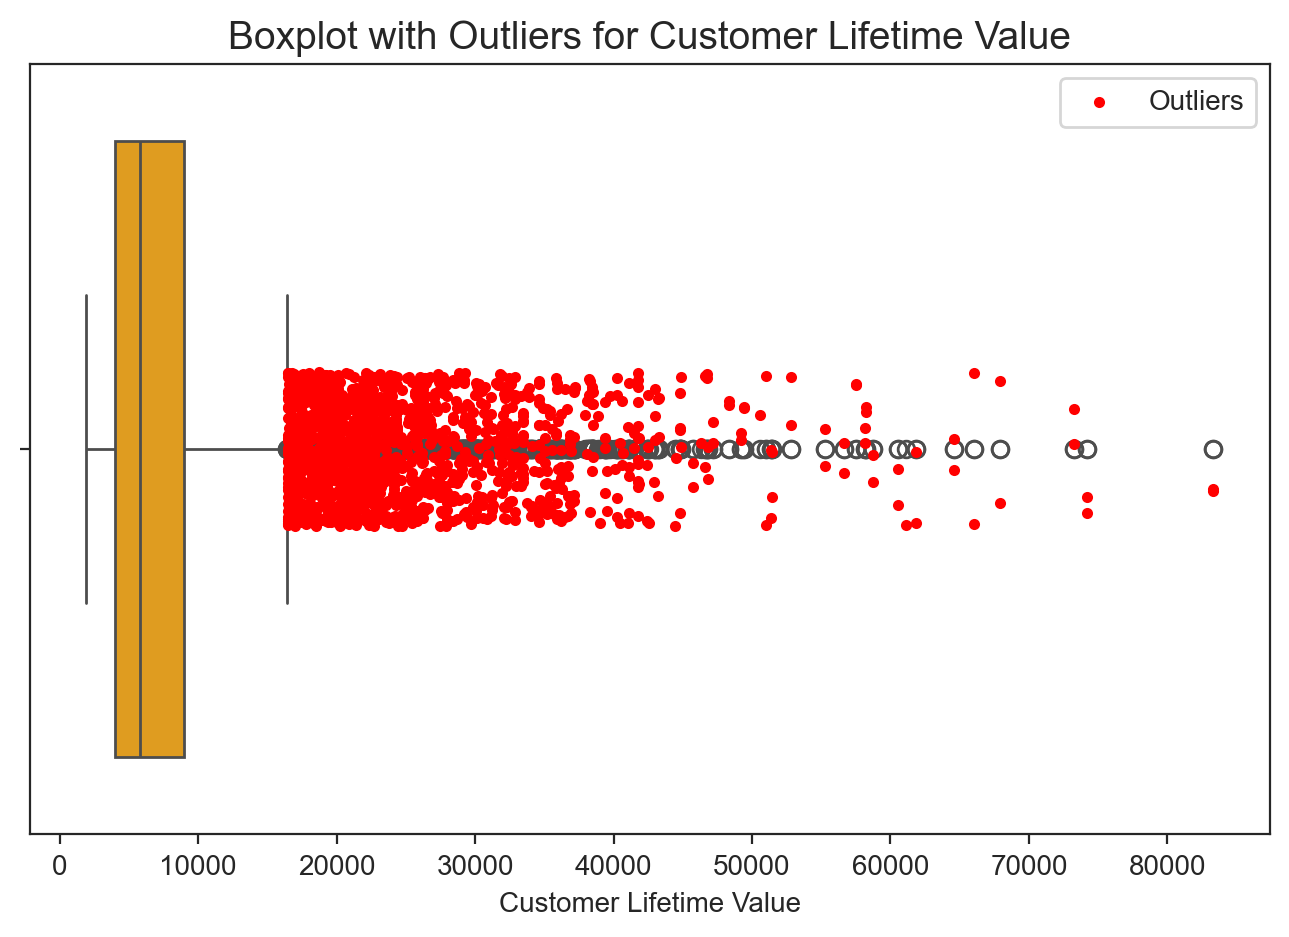

Column: Income - Number of Outliers: 0
Column: Income - % of Outliers: 0.00%



C:\Users\Francisco Martins\AppData\Local\Temp\ipykernel_15872\2753299276.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


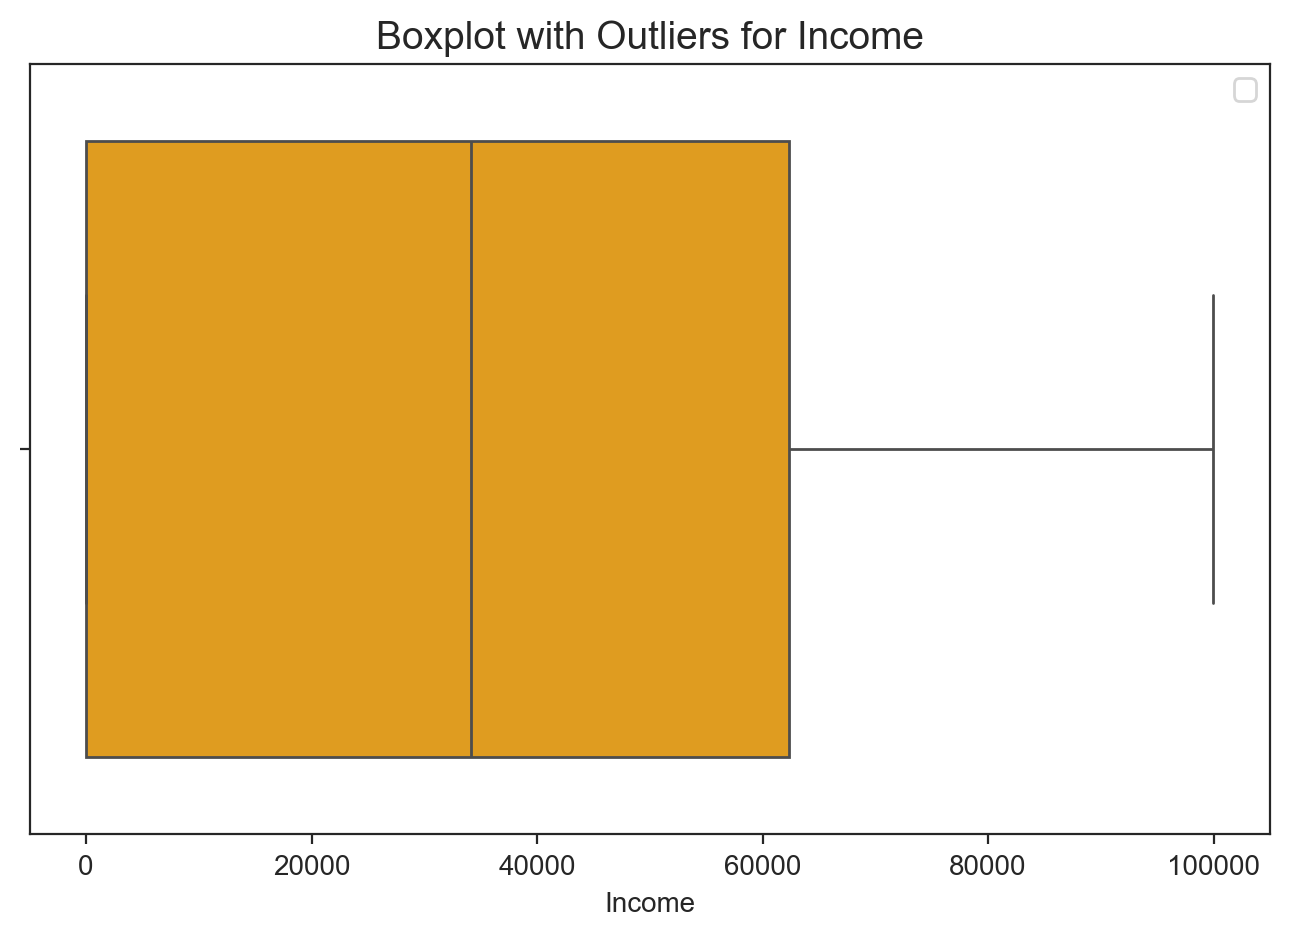

Column: Days_sub - Number of Outliers: 0
Column: Days_sub - % of Outliers: 0.00%



C:\Users\Francisco Martins\AppData\Local\Temp\ipykernel_15872\2753299276.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


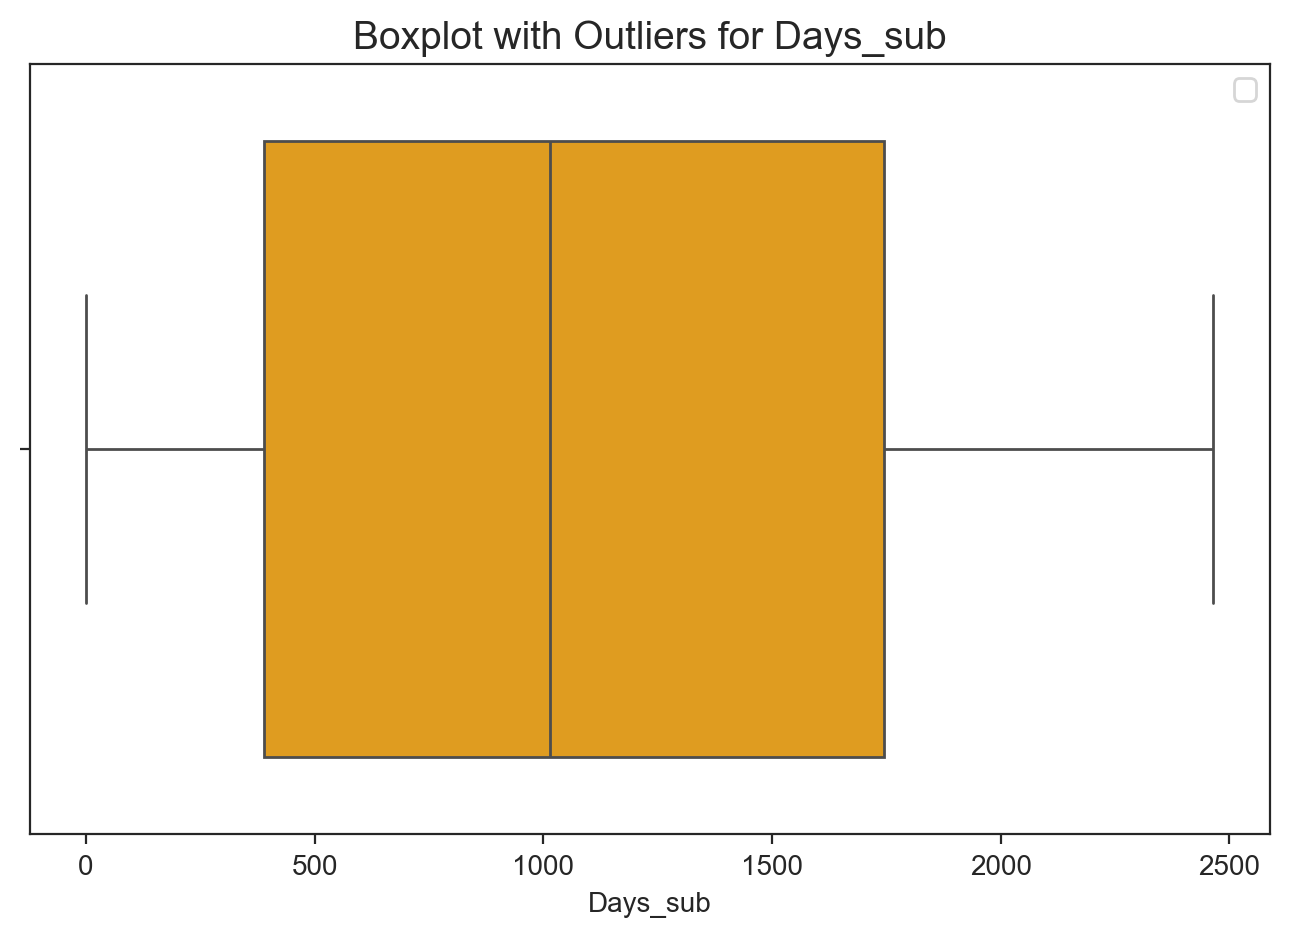

,Column,Num_Outliers,Pct_Outliers
0,Customer Lifetime Value,1460,8.798361


In [670]:
detect_outliers_iqr(df_c[df_c_metric], 0.001)

We only observe missing values for **Customer Lifetime Value**

In [671]:
df_c.loc[df_c['Customer Lifetime Value']>50000]

,Loyalty#,Province or State,City,Gender,Education,Income,Marital Status,LoyaltyStatus,Customer Lifetime Value,EnrollmentType,Days_sub
4149,364710,Quebec,Tremblant,female,Bachelor,25167,Married,Aurora,51016.07,2021 Promotion,270
4150,566374,New Brunswick,Moncton,female,Bachelor,25167,Married,Aurora,51016.07,Standard,902
4151,333051,New Brunswick,Moncton,male,Bachelor,84650,Married,Aurora,51426.25,2021 Promotion,244
4152,642323,Ontario,Toronto,male,College,0,Married,Aurora,52811.49,Standard,372
4153,798869,New Brunswick,Fredericton,male,Bachelor,40740,Single,Aurora,55277.45,Standard,68
4154,977244,Quebec,Montreal,female,Bachelor,77237,Married,Aurora,56675.94,Standard,1366
4155,801738,Saskatchewan,Regina,female,Bachelor,48367,Married,Aurora,57520.50,2021 Promotion,331
4156,219139,Alberta,Banff,female,Bachelor,61321,Single,Aurora,58166.55,Standard,1025
4157,228030,British Columbia,Vancouver,male,Bachelor,24964,Married,Aurora,58753.88,Standard,851
4158,592992,Ontario,Trenton,male,College,0,Married,Aurora,61850.19,Standard,2000


***

<h1>df_f

In [672]:
df_f.columns

Index(['Loyalty#', 'Year', 'Month', 'NumFlights', 'NumFlightsWithCompanions',
       'DistanceKM', 'PointsAccumulated', 'PointsRedeemed',
       'DollarCostPointsRedeemed', 'AvgFlightDistance_month'],
      dtype='object')

In [673]:
df_f_out = ['NumFlights','NumFlightsWithCompanions','DistanceKM','PointsRedeemed', 'AvgFlightDistance_month']

Column: NumFlights - Number of Outliers: 519
Column: NumFlights - % of Outliers: 0.09%



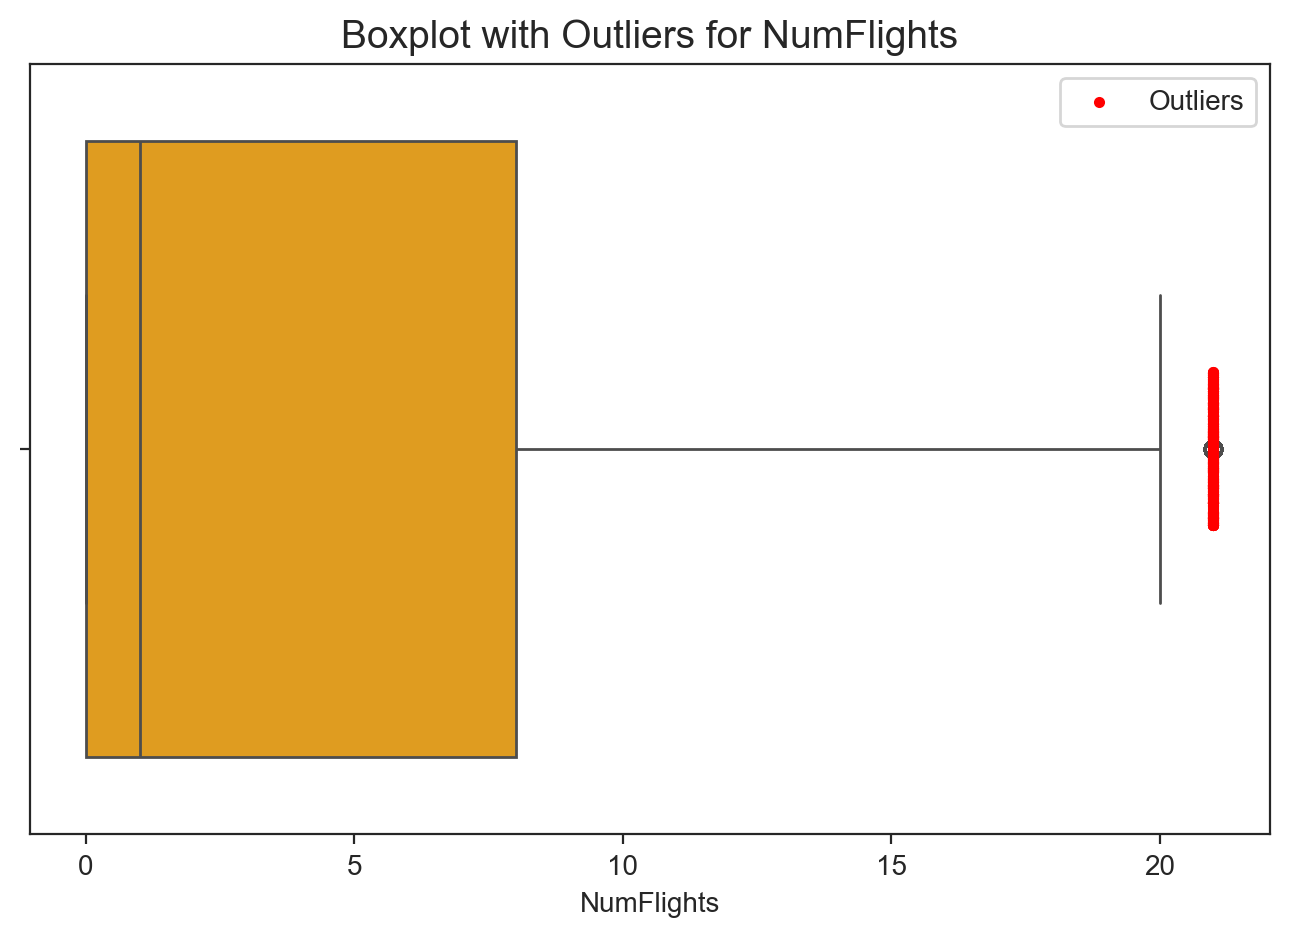

Column: NumFlightsWithCompanions - Number of Outliers: 95880
Column: NumFlightsWithCompanions - % of Outliers: 16.07%



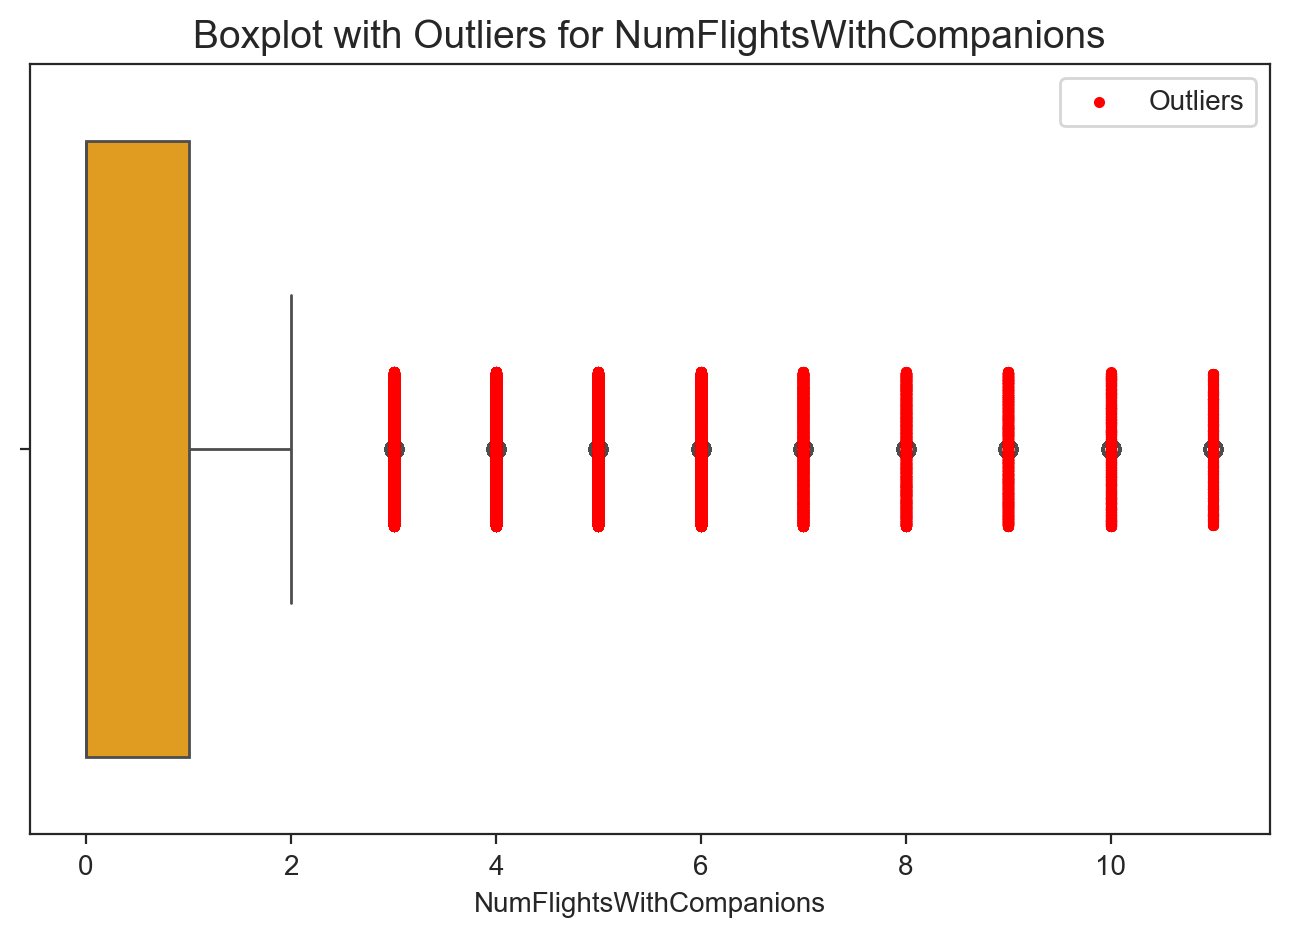

Column: DistanceKM - Number of Outliers: 1828
Column: DistanceKM - % of Outliers: 0.31%



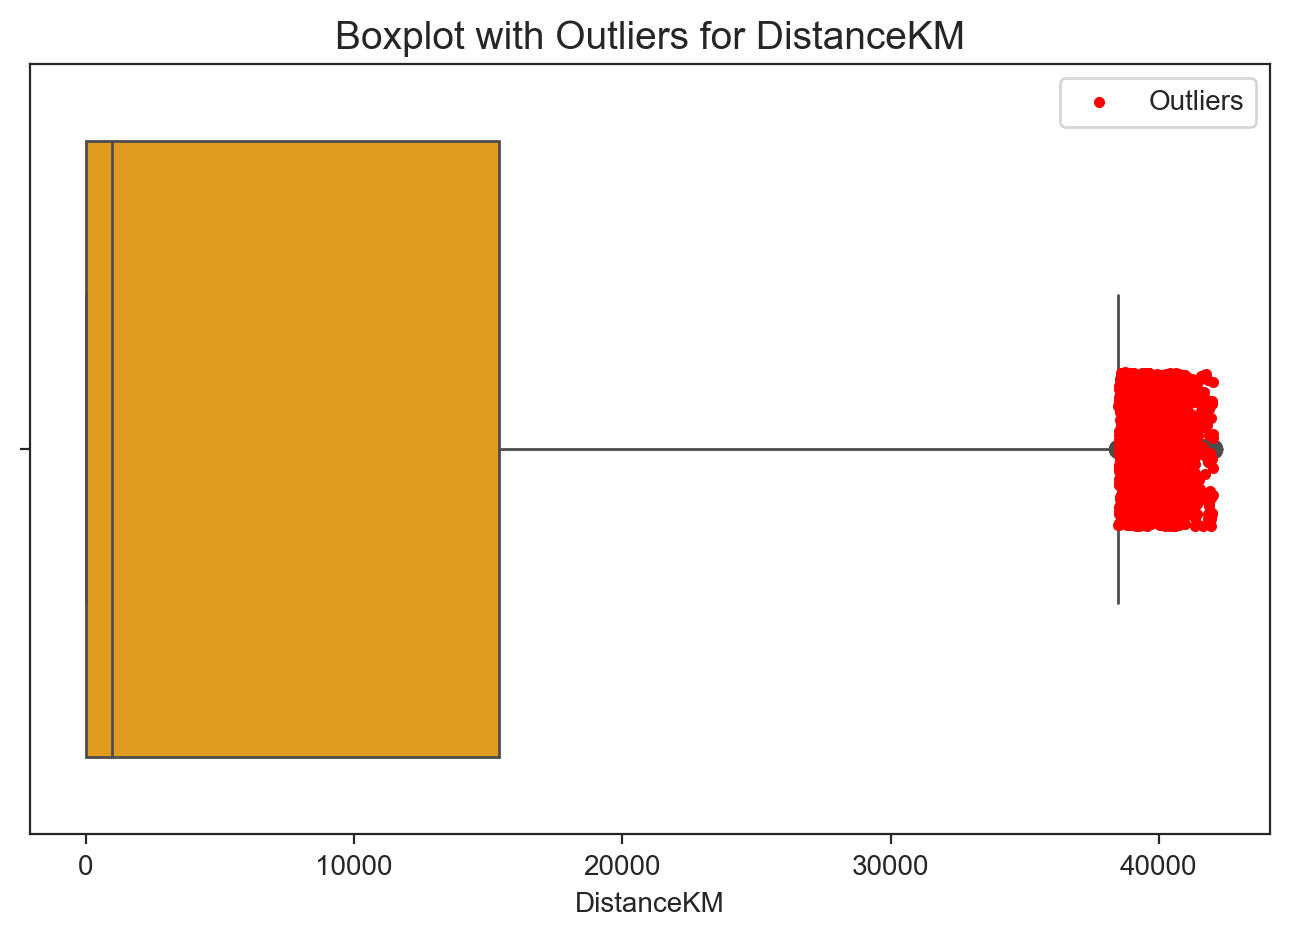

Column: PointsRedeemed - Number of Outliers: 34884
Column: PointsRedeemed - % of Outliers: 5.85%



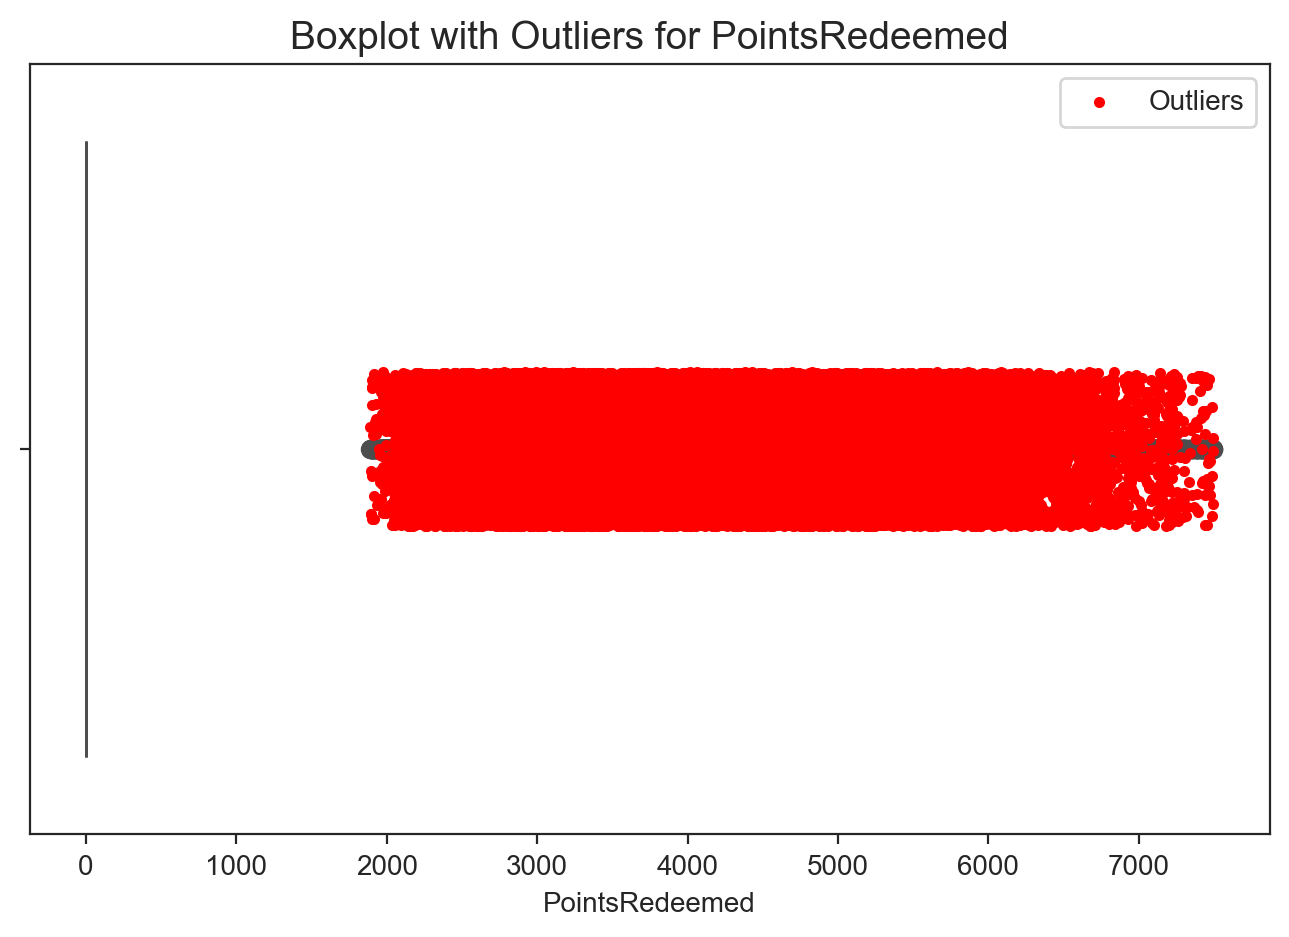

Column: AvgFlightDistance_month - Number of Outliers: 52947
Column: AvgFlightDistance_month - % of Outliers: 8.87%



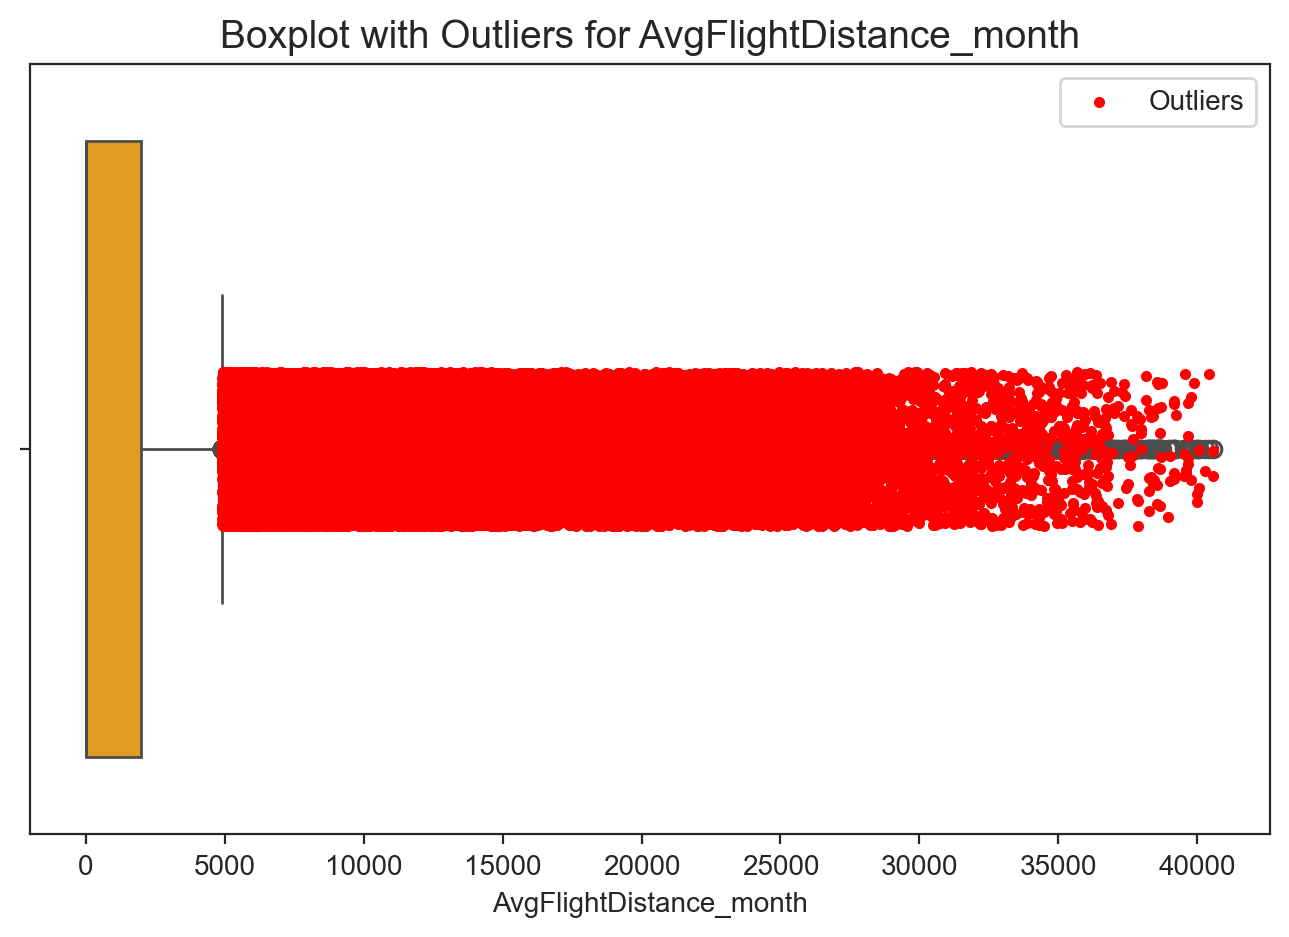

,Column,Num_Outliers,Pct_Outliers
0,NumFlightsWithCompanions,95880,16.069346
1,DistanceKM,1828,0.306370
2,PointsRedeemed,34884,5.846507
3,AvgFlightDistance_month,52947,8.873839


In [674]:
detect_outliers_iqr(df_f[df_f_out], 0.001)

<h2>NumFlightsWithCompanions

In [675]:
df_f[df_f['NumFlightsWithCompanions'] == 5].shape

(18343, 10)

In [676]:
df_f[df_f['NumFlightsWithCompanions'] == 10].shape

(1051, 10)

Lower NumFlightsWithCompanions values have more observations, as expected.

<h2>AvgFlightDistance_month

AvgFlightDistance_month measures the average distance traveled per flight by a customer in a single month. The longest flight in 2025 is New York (JFK) – Singapore (SIN) with 15,349 km (9,537 mi) of Flight Distance (https://airinsight.com/top-10-longest-flights-in-2025/). This means that AvgFlightDistance_month values above 15.349 KM are unrealistic and probably an identation error of NumFlights or DistanceKM.

In [677]:
df_f[df_f['AvgFlightDistance_month']>15349].sample(10)

,Loyalty#,Year,Month,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed,AvgFlightDistance_month
208730,706792,2021,6,1.0,0,34225.0,3422.00,0.0,0.0,34225.0
516501,604681,2019,7,1.0,0,27970.2,2797.02,0.0,0.0,27970.2
216635,621951,2021,6,1.0,1,17685.0,1768.00,6411.0,64.0,17685.0
467404,688820,2019,4,1.0,1,24518.7,2451.87,4185.9,41.4,24518.7
309715,214661,2020,12,2.0,2,32164.0,3216.00,0.0,0.0,16082.0
281494,947620,2021,1,1.0,0,22001.0,2200.00,0.0,0.0,22001.0
50479,239956,2020,3,1.0,0,30284.0,3028.00,0.0,0.0,30284.0
163625,438707,2021,12,1.0,0,23855.0,2385.00,0.0,0.0,23855.0
115294,635907,2021,10,1.0,1,18185.0,1818.00,0.0,0.0,18185.0
501447,702284,2019,6,1.0,0,26138.7,2613.87,0.0,0.0,26138.7


All of these flights have 1-2 Number of flights in that month (NumFlights) and DistanceKM is in sinc with PointAccumulated. It looks like an identation error from NumFlights variable. Therefore we will set those as missing values to impute them later.

In [678]:
#set NumFlights where AvgFlightDistance_month is >15349 to NaN
df_f.loc[df_f['AvgFlightDistance_month']>15349, 'NumFlights'] = np.nan

## Imputing NumFlights missing values

Before aggregating the flights dataset by customer and merging customers and flight dataset, we will impute the Numflights missing values with a KNN imputer

In [679]:
df_f.isna().sum()

Loyalty#                        0
Year                            0
Month                           0
NumFlights                  21530
NumFlightsWithCompanions        0
DistanceKM                      0
PointsAccumulated               0
PointsRedeemed                  0
DollarCostPointsRedeemed        0
AvgFlightDistance_month         0
dtype: int64

In [680]:
knn_feat = ['Year', 'Month', 'NumFlights', 'DistanceKM']

In [681]:
imputer = KNNImputer(n_neighbors=5, weights="uniform")

imputer.fit(df_f[knn_feat])
df_f[knn_feat] = imputer.transform(df_f[knn_feat])

In [682]:
df_f = df_f.drop(columns=['AvgFlightDistance_month'])

df_f['AvgFlightDistance_month'] = np.where(
    df_f['NumFlights'] > 0,
    df_f['DistanceKM'] / df_f['NumFlights'],
    0
)

In [683]:
df_f[df_f['AvgFlightDistance_month']>15349]

,Loyalty#,Year,Month,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed,AvgFlightDistance_month


Now there are NumFlights values with decimal cases, lets fix it by rounding the number

In [684]:
df_f[(df_f['NumFlights'] < 3) & (df_f['NumFlights'] > 2)].sample(3)

,Loyalty#,Year,Month,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed,AvgFlightDistance_month
121094,223313,2021.0,11.0,2.2,0,23338.0,2333.00,0.0,0.0,10608.181818
533261,597267,2019.0,8.0,2.2,0,10129.5,1012.95,0.0,0.0,4604.318182
183687,467945,2021.0,9.0,2.6,1,28907.0,2890.00,0.0,0.0,11118.076923


In [685]:
df_f['NumFlights'] = df_f['NumFlights'].round()

df_f = df_f.drop(columns=['AvgFlightDistance_month'])

df_f['AvgFlightDistance_month'] = np.where(
    df_f['NumFlights'] > 0,
    df_f['DistanceKM'] / df_f['NumFlights'],
    0
)

df_f[df_f['AvgFlightDistance_month']>15349]

,Loyalty#,Year,Month,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed,AvgFlightDistance_month


## Aggregate Flights dataset by customer

In [686]:
# Aggregate by client - Loyalty 
df_f_agg = (df_f.groupby("Loyalty#").agg(
    {"Year": ["nunique"],                     
    "Month": ["nunique"],                    
    "NumFlights": ["sum", "mean", "max"],    
    "NumFlightsWithCompanions": ["sum", "mean"],  
    "DistanceKM": ["sum", "mean", "max"],    
    "PointsAccumulated": ["sum", "mean"],    
    "PointsRedeemed": ["sum", "mean"],       
    "DollarCostPointsRedeemed": ["sum", "mean"]}).reset_index())

# I know there are a lot of variables, but u never know if we will use them. In the end, they can be removed
df_f_agg.columns = ["Loyalty#", "Years_Active", "Months_Active", "Flights_Sum", "Flights_Mean", "Flights_Max",
                          "FlightsComp_Sum", "FlightsComp_Mean", "DistKM_Sum", "DistKM_Mean", "DistKM_Max", "PtsAcc_Sum", "PtsAcc_Mean",
                          "PtsRed_Sum", "PtsRed_Mean", "CostPts_Sum", "CostPts_Mean"]

# Feature Engineering (some variables created that could be important)
# Ratio between Points Redeemed and Points Accumulated over the time
df_f_agg["PointsEfficiency"] = (
    df_f_agg["PtsRed_Sum"] / df_f_agg["PtsAcc_Sum"]
).replace([np.inf, np.nan], 0)

# Distance
df_f_agg["DistPerFlight"] = (
    df_f_agg["DistKM_Sum"] / df_f_agg["Flights_Sum"]
).replace([np.inf, np.nan], 0)


In [687]:
df_f_agg.sample(10)

,Loyalty#,Years_Active,Months_Active,Flights_Sum,Flights_Mean,Flights_Max,FlightsComp_Sum,FlightsComp_Mean,DistKM_Sum,DistKM_Mean,DistKM_Max,PtsAcc_Sum,PtsAcc_Mean,PtsRed_Sum,PtsRed_Mean,CostPts_Sum,CostPts_Mean,PointsEfficiency,DistPerFlight
1992,207860,3,12,75.0,2.083333,17.0,20,0.555556,140316.4,3897.677778,31336.0,14029.24,389.701111,3530.0,98.055556,35.0,0.972222,0.251617,1870.885333
15641,948783,3,12,189.0,5.250000,16.0,41,1.138889,365858.3,10162.730556,38311.0,36579.73,1016.103611,21346.8,592.966667,211.1,5.863889,0.583569,1935.758201
235,113184,3,12,45.0,1.250000,14.0,1,0.027778,75049.0,2084.694444,25572.0,7503.00,208.416667,0.0,0.000000,0.0,0.000000,0.000000,1667.755556
3251,276947,3,12,154.0,4.277778,14.0,41,1.138889,298531.2,8292.533333,37692.0,29848.52,829.125556,6964.0,193.444444,69.0,1.916667,0.233311,1938.514286
13011,803084,3,12,24.0,0.666667,10.0,2,0.055556,51625.0,1434.027778,27239.0,5160.00,143.333333,0.0,0.000000,0.0,0.000000,0.000000,2151.041667
10261,655480,3,12,194.0,5.388889,17.0,50,1.388889,401601.6,11155.600000,27414.0,40151.96,1115.332222,11741.9,326.163889,115.6,3.211111,0.292437,2070.111340
8385,555205,3,12,193.0,5.361111,17.0,19,0.527778,403059.6,11196.100000,33410.0,40300.86,1119.468333,5206.0,144.611111,51.3,1.425000,0.129178,2088.391710
678,137106,3,12,136.0,3.777778,11.0,53,1.472222,339128.6,9420.238889,35874.0,33907.66,941.879444,9889.7,274.713889,97.5,2.708333,0.291666,2493.592647
16092,972157,3,12,214.0,5.944444,17.0,62,1.722222,503435.8,13984.327778,34934.0,50335.58,1398.210556,9762.0,271.166667,96.4,2.677778,0.193938,2352.503738
1013,155820,3,12,227.0,6.305556,19.0,54,1.500000,411269.2,11424.144444,36863.0,41120.32,1142.231111,7892.8,219.244444,76.6,2.127778,0.191944,1811.758590


As we can see, for all the customers, the "Years_Active" and "Months_Active" are the same, so we are going to drop both.

In [688]:
df_f_agg = df_f_agg.drop(['Years_Active', 'Months_Active'], axis=1)

## Missing Values

Let's treat the Missing Values before Merging the datasets

In [689]:
df_c.isna().sum()

Loyalty#                    0
Province or State           0
City                        0
Gender                      0
Education                   0
Income                     20
Marital Status              0
LoyaltyStatus               0
Customer Lifetime Value    20
EnrollmentType              0
Days_sub                    0
dtype: int64

In [690]:
#lets the the rows where income is Nan
df_c[df_c['Income'].isna()]

,Loyalty#,Province or State,City,Gender,Education,Income,Marital Status,LoyaltyStatus,Customer Lifetime Value,EnrollmentType,Days_sub
0,999987,New Brunswick,Fredericton,female,Bachelor,<NA>,Single,Star,NaN,Standard,0
1,999988,Quebec,Montreal,male,College,<NA>,Single,Star,NaN,Standard,0
2,999989,Ontario,Trenton,male,College,<NA>,Married,Star,NaN,Standard,0
3,999990,New Brunswick,Moncton,female,College,<NA>,Married,Star,NaN,Standard,0
4,999991,New Brunswick,Fredericton,female,College,<NA>,Married,Star,NaN,Standard,0
5,999992,Ontario,Toronto,male,College,<NA>,Single,Star,NaN,Standard,0
6,999993,British Columbia,Dawson Creek,female,College,<NA>,Married,Star,NaN,Standard,0
7,999994,Ontario,Ottawa,female,College,<NA>,Married,Star,NaN,Standard,0
8,999995,Ontario,Ottawa,female,College,<NA>,Married,Star,NaN,Standard,0
9,999996,Ontario,Toronto,female,Bachelor,<NA>,Single,Star,NaN,Standard,0


The rows where income is Na are the rows where Customer Lifetime Value is also NaN. Lets see these customers on the flights dataset

In [691]:
Nan_customer_ids = df_c[df_c['Income'].isna()]['Loyalty#'].tolist()

df_f[df_f['Loyalty#'].isin(Nan_customer_ids)]

,Loyalty#,Year,Month,NumFlights,NumFlightsWithCompanions,DistanceKM,PointsAccumulated,PointsRedeemed,DollarCostPointsRedeemed,AvgFlightDistance_month


The customers that have missing values on income and Customer Lifetime Value dont exist in the flights dataset so we will just remove them.

In [692]:
#remove these customers from customer dataset
df_c = df_c[~df_c['Loyalty#'].isin(Nan_customer_ids)].copy()

## Merge both datasets

In [693]:
df_agg_merged = pd.merge(df_c, df_f_agg, on="Loyalty#", how="left")
print("Final dimensions:", df_agg_merged.shape)

Final dimensions: (16574, 27)


In [694]:
df_agg_merged.columns

Index(['Loyalty#', 'Province or State', 'City', 'Gender', 'Education',
       'Income', 'Marital Status', 'LoyaltyStatus', 'Customer Lifetime Value',
       'EnrollmentType', 'Days_sub', 'Flights_Sum', 'Flights_Mean',
       'Flights_Max', 'FlightsComp_Sum', 'FlightsComp_Mean', 'DistKM_Sum',
       'DistKM_Mean', 'DistKM_Max', 'PtsAcc_Sum', 'PtsAcc_Mean', 'PtsRed_Sum',
       'PtsRed_Mean', 'CostPts_Sum', 'CostPts_Mean', 'PointsEfficiency',
       'DistPerFlight'],
      dtype='object')

### Check outliers

We had checked outliers for df_c and df_f. But with the new flights dataset aggregated by customer we have created new variables.

In [695]:
df_agg_merged_out = ['Income', 'Customer Lifetime Value',
       'Days_sub', 'Flights_Sum',
       'Flights_Mean', 'Flights_Max', 'FlightsComp_Sum', 'FlightsComp_Mean',
       'DistKM_Sum', 'DistKM_Mean', 'DistKM_Max', 'PtsAcc_Sum', 'PtsAcc_Mean',
       'PtsRed_Sum', 'PtsRed_Mean', 'CostPts_Sum', 'CostPts_Mean',
       'PointsEfficiency', 'DistPerFlight']

Column: Income - Number of Outliers: 0
Column: Income - % of Outliers: 0.00%



C:\Users\Francisco Martins\AppData\Local\Temp\ipykernel_15872\2753299276.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


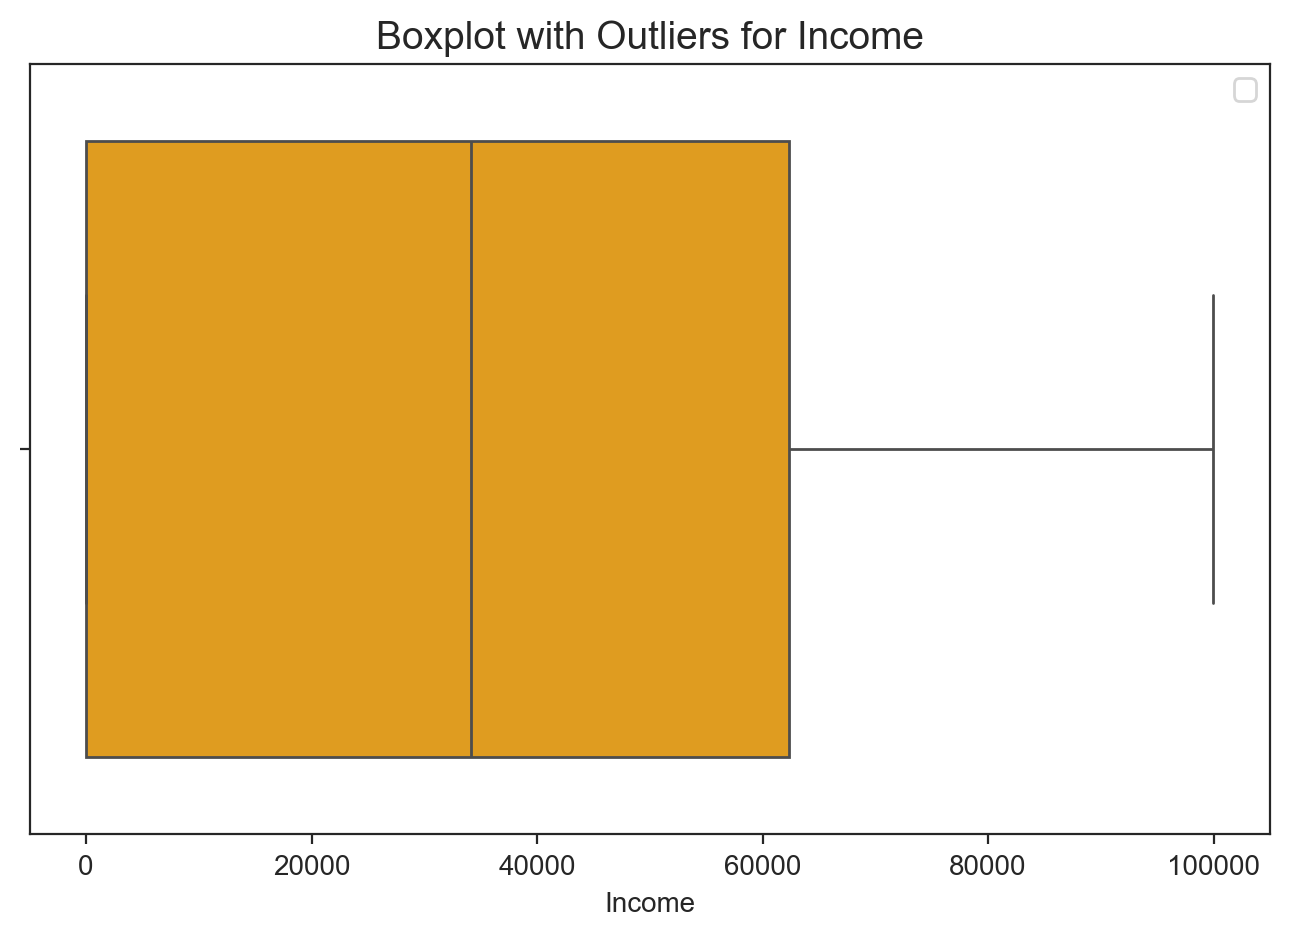

Column: Customer Lifetime Value - Number of Outliers: 1460
Column: Customer Lifetime Value - % of Outliers: 8.81%



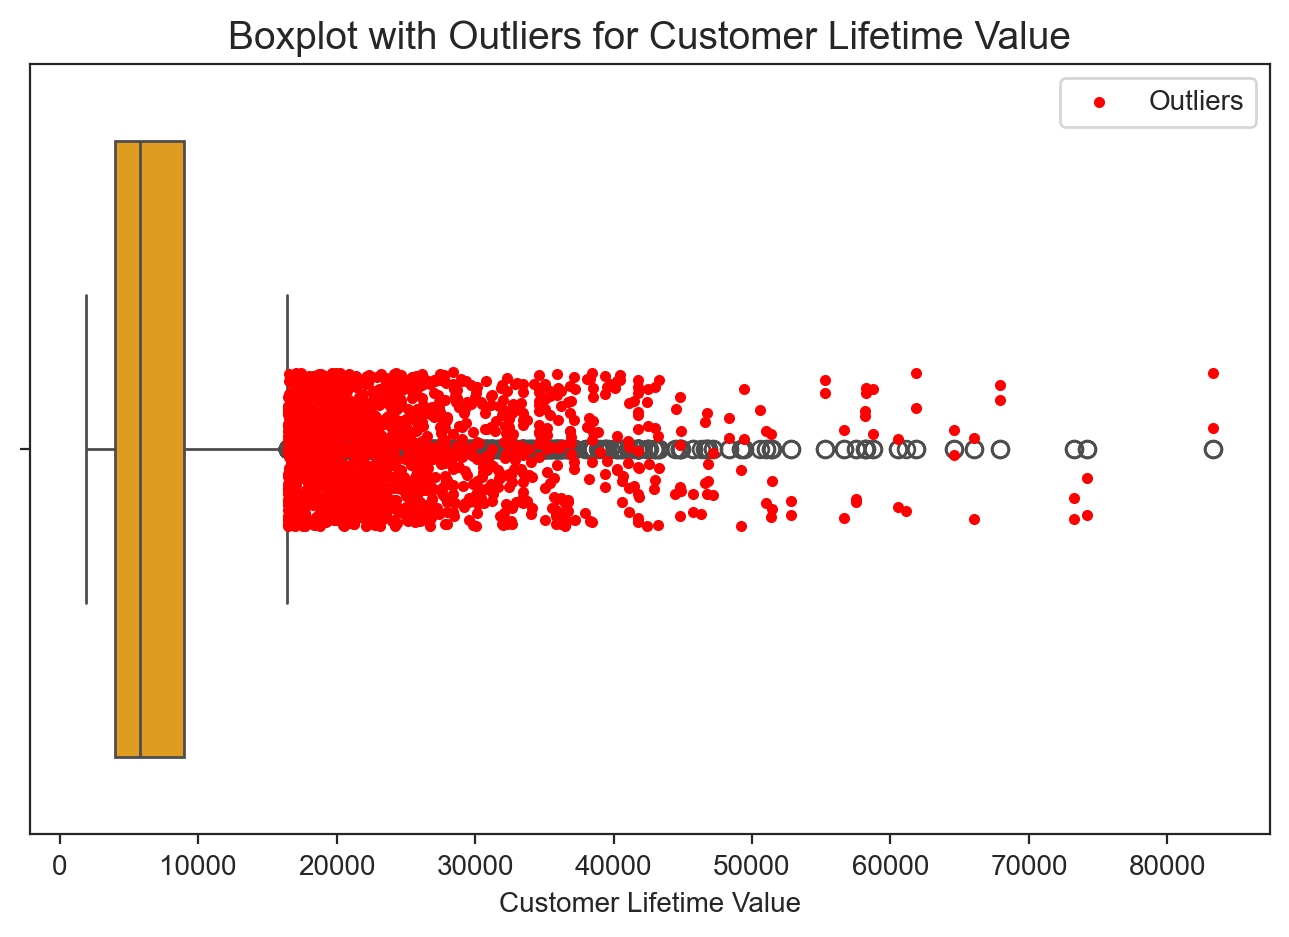

Column: Days_sub - Number of Outliers: 0
Column: Days_sub - % of Outliers: 0.00%



C:\Users\Francisco Martins\AppData\Local\Temp\ipykernel_15872\2753299276.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


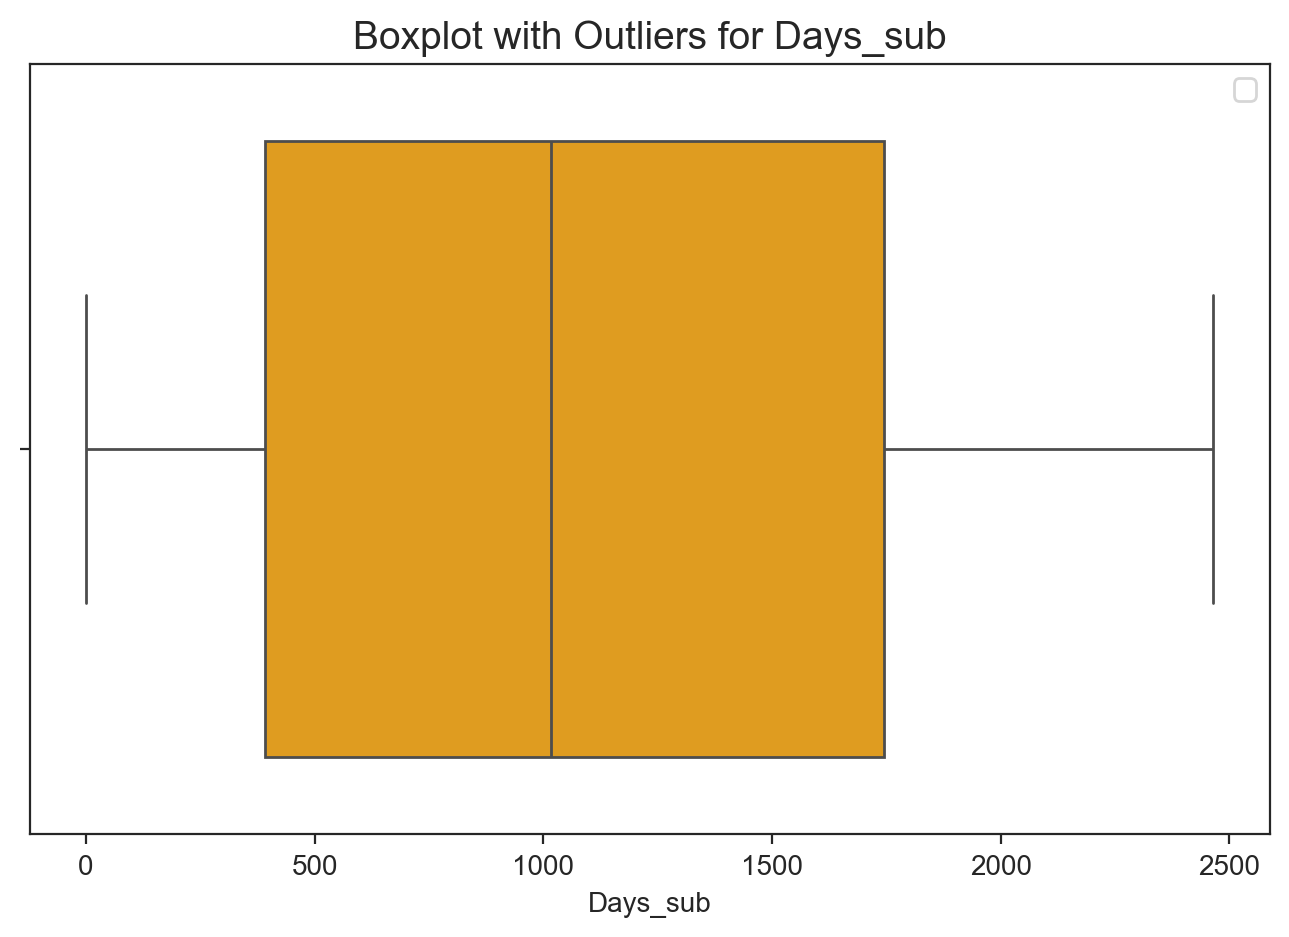

Column: Flights_Sum - Number of Outliers: 0
Column: Flights_Sum - % of Outliers: 0.00%



C:\Users\Francisco Martins\AppData\Local\Temp\ipykernel_15872\2753299276.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


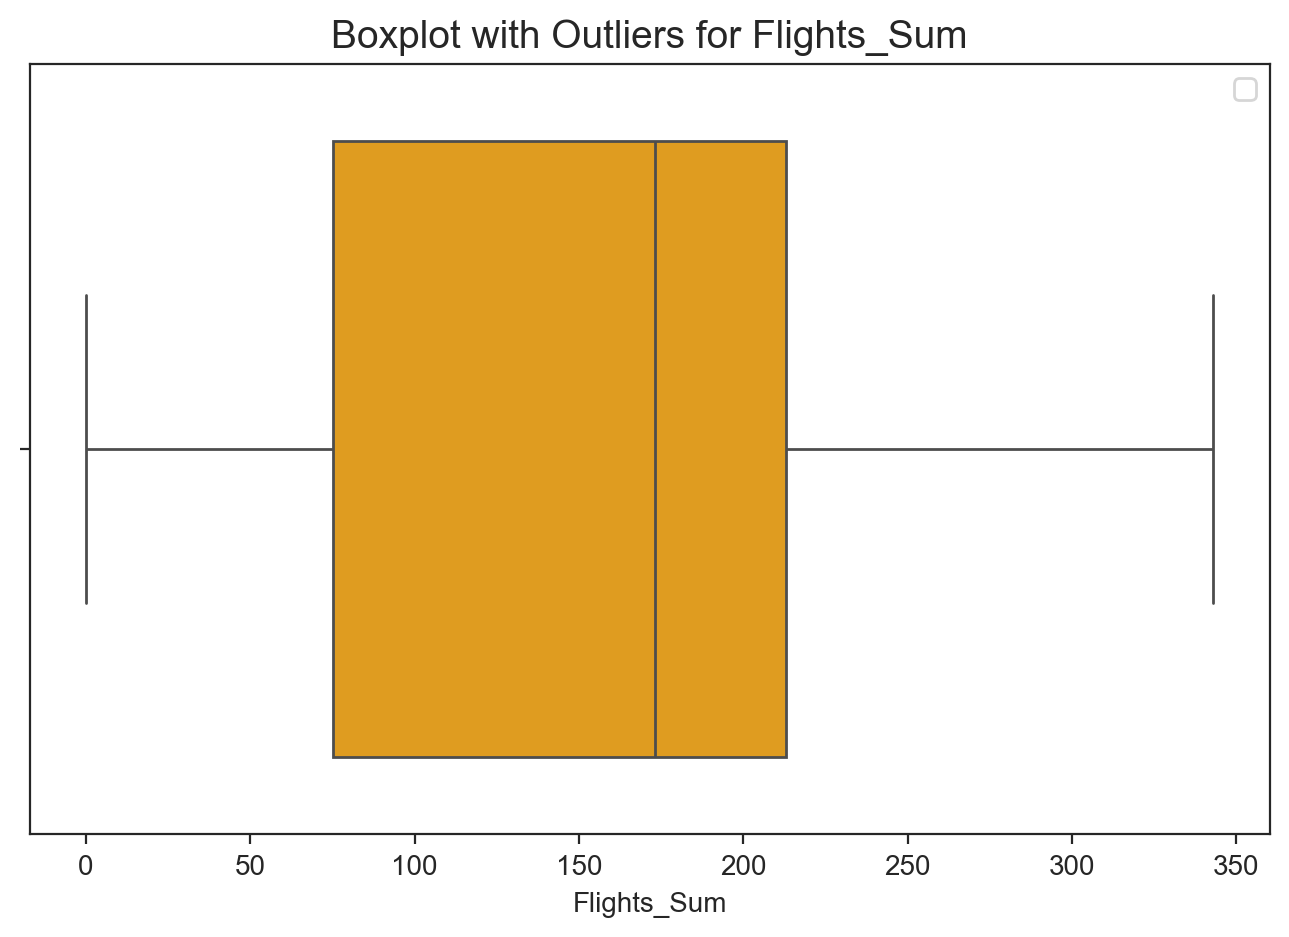

Column: Flights_Mean - Number of Outliers: 0
Column: Flights_Mean - % of Outliers: 0.00%



C:\Users\Francisco Martins\AppData\Local\Temp\ipykernel_15872\2753299276.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


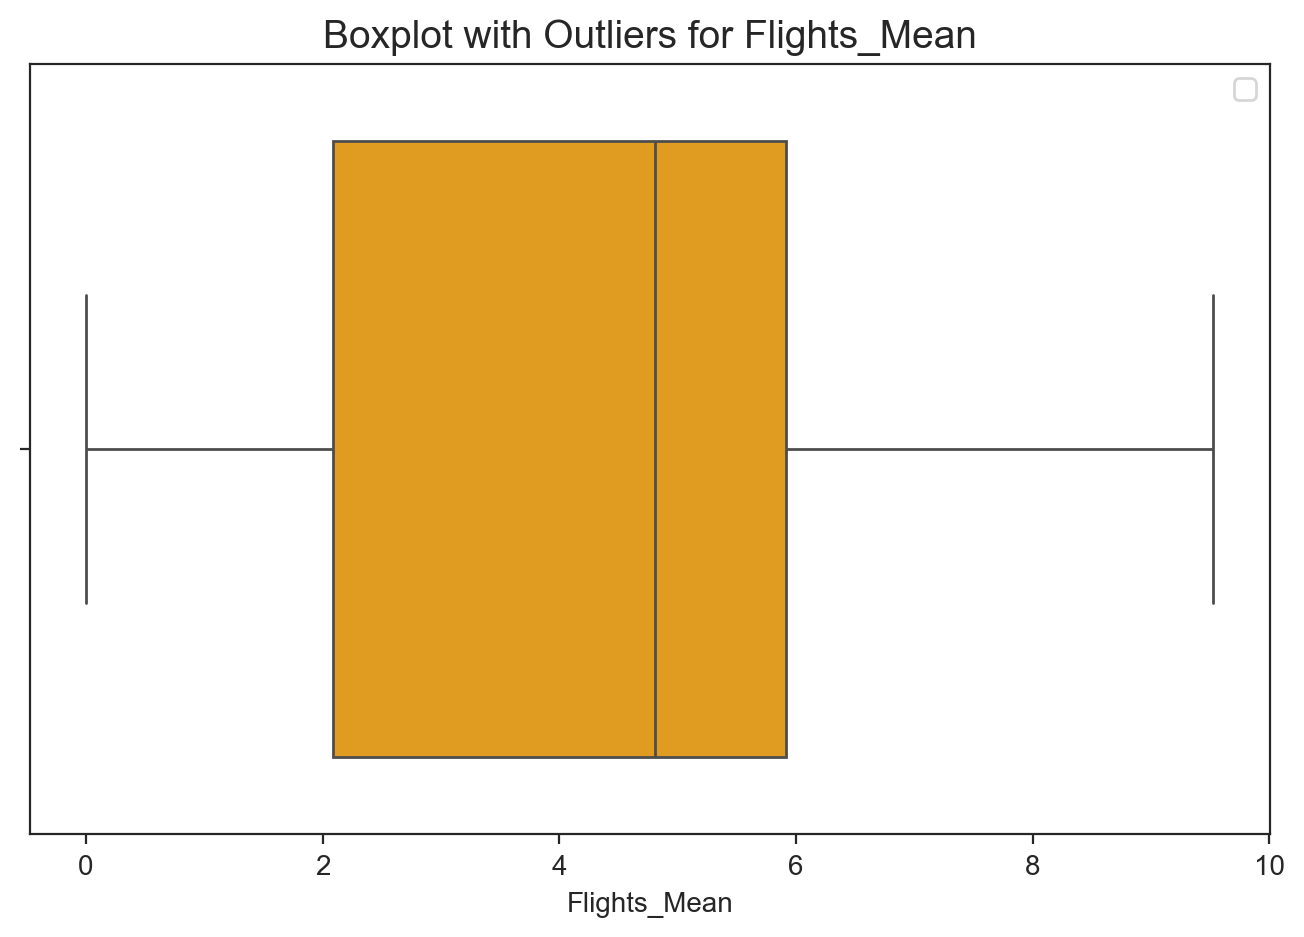

Column: Flights_Max - Number of Outliers: 1620
Column: Flights_Max - % of Outliers: 9.77%



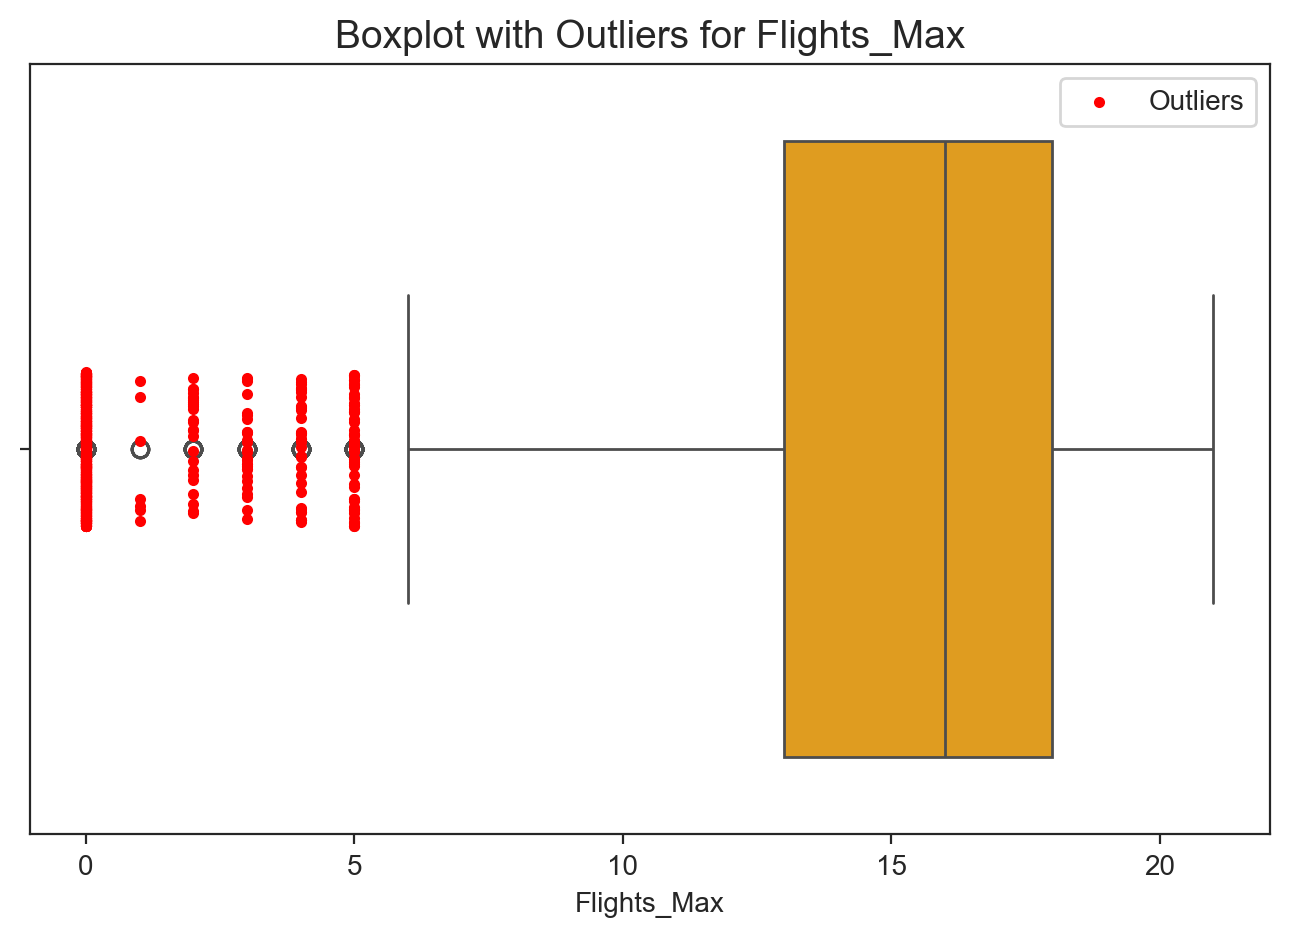

Column: FlightsComp_Sum - Number of Outliers: 18
Column: FlightsComp_Sum - % of Outliers: 0.11%



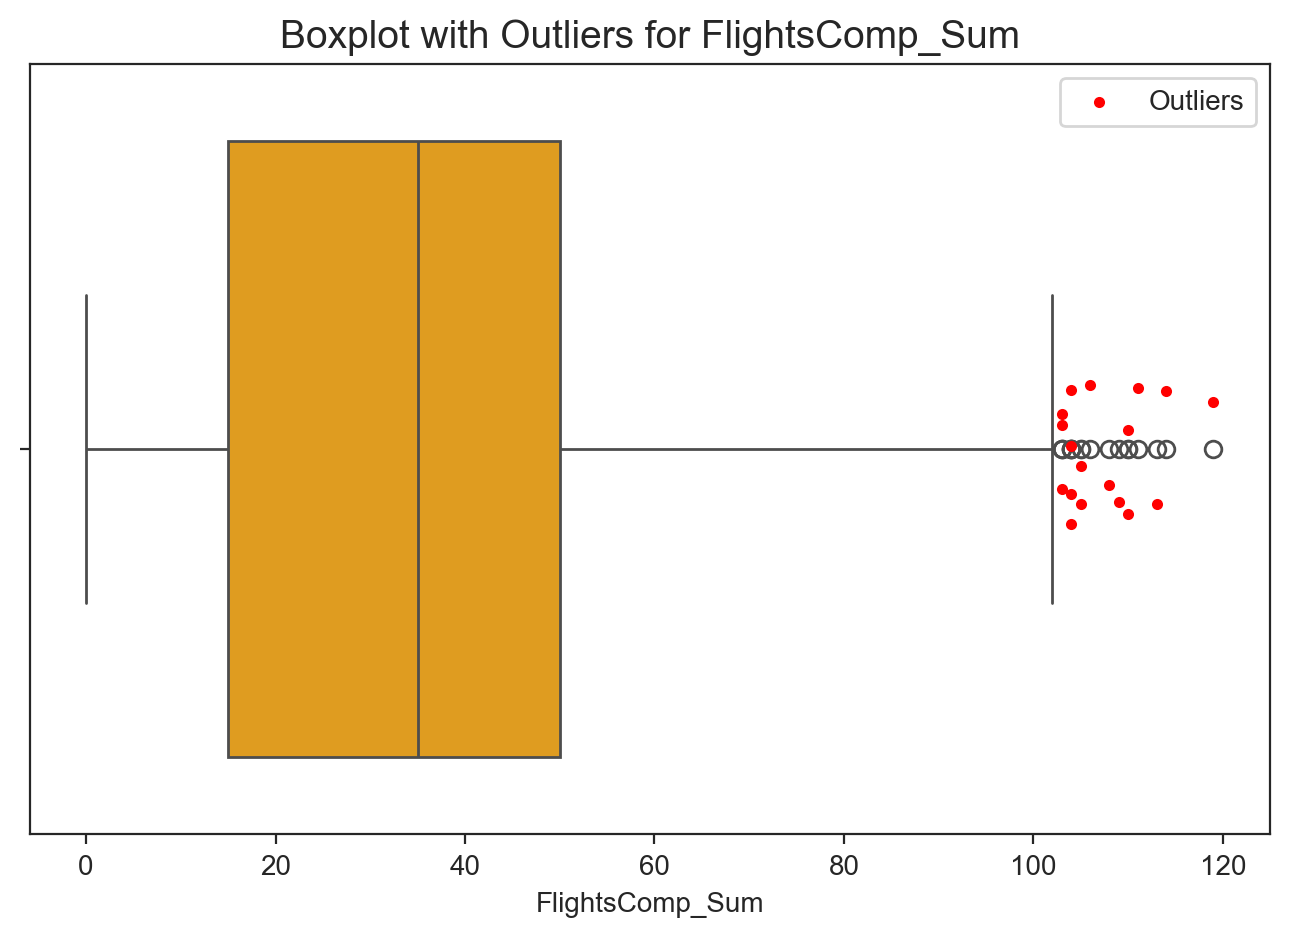

Column: FlightsComp_Mean - Number of Outliers: 18
Column: FlightsComp_Mean - % of Outliers: 0.11%



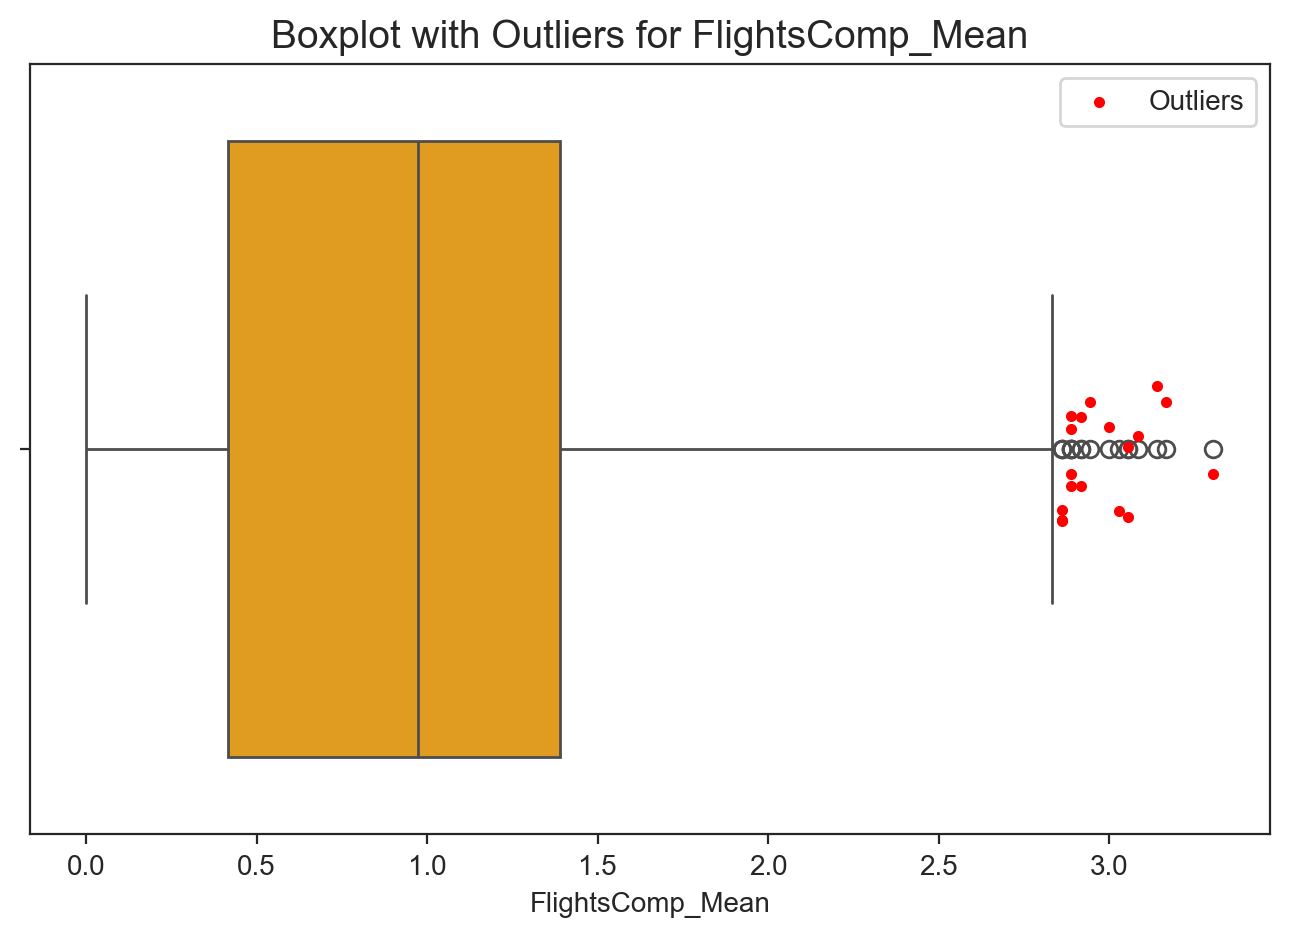

Column: DistKM_Sum - Number of Outliers: 0
Column: DistKM_Sum - % of Outliers: 0.00%



C:\Users\Francisco Martins\AppData\Local\Temp\ipykernel_15872\2753299276.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


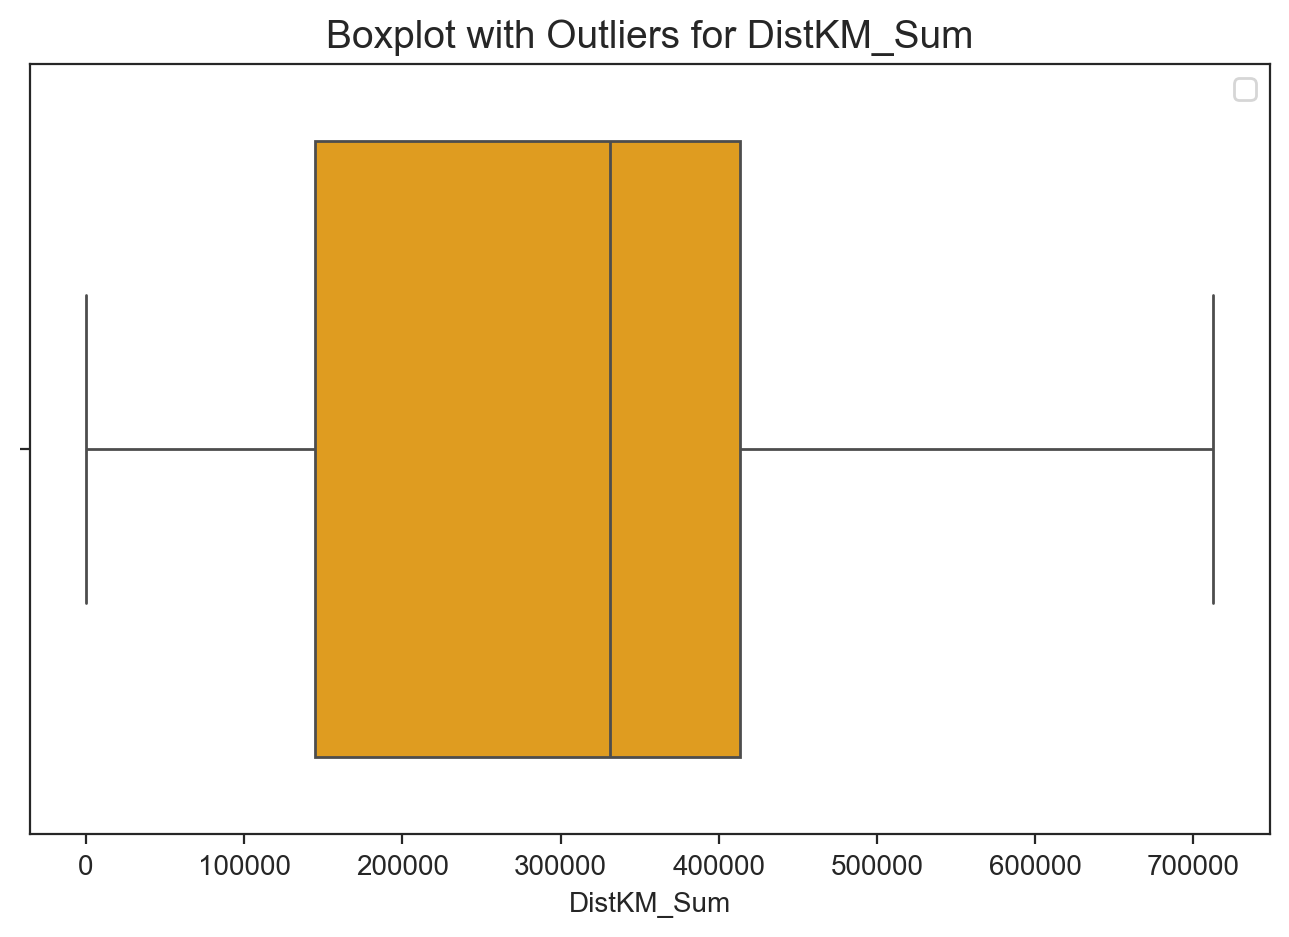

C:\Users\Francisco Martins\AppData\Local\Temp\ipykernel_15872\2753299276.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Column: DistKM_Mean - Number of Outliers: 0
Column: DistKM_Mean - % of Outliers: 0.00%



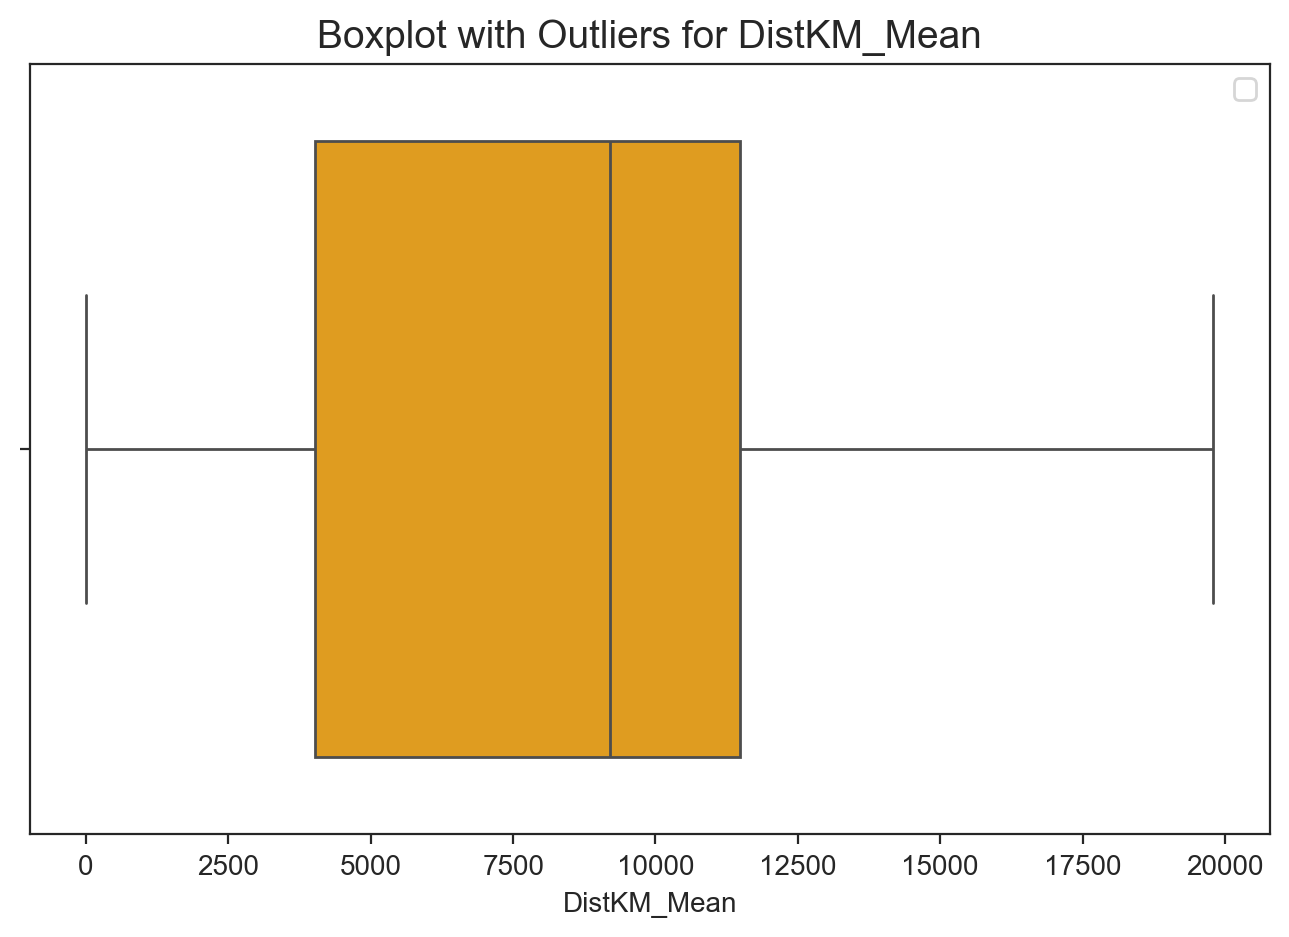

Column: DistKM_Max - Number of Outliers: 1808
Column: DistKM_Max - % of Outliers: 10.91%



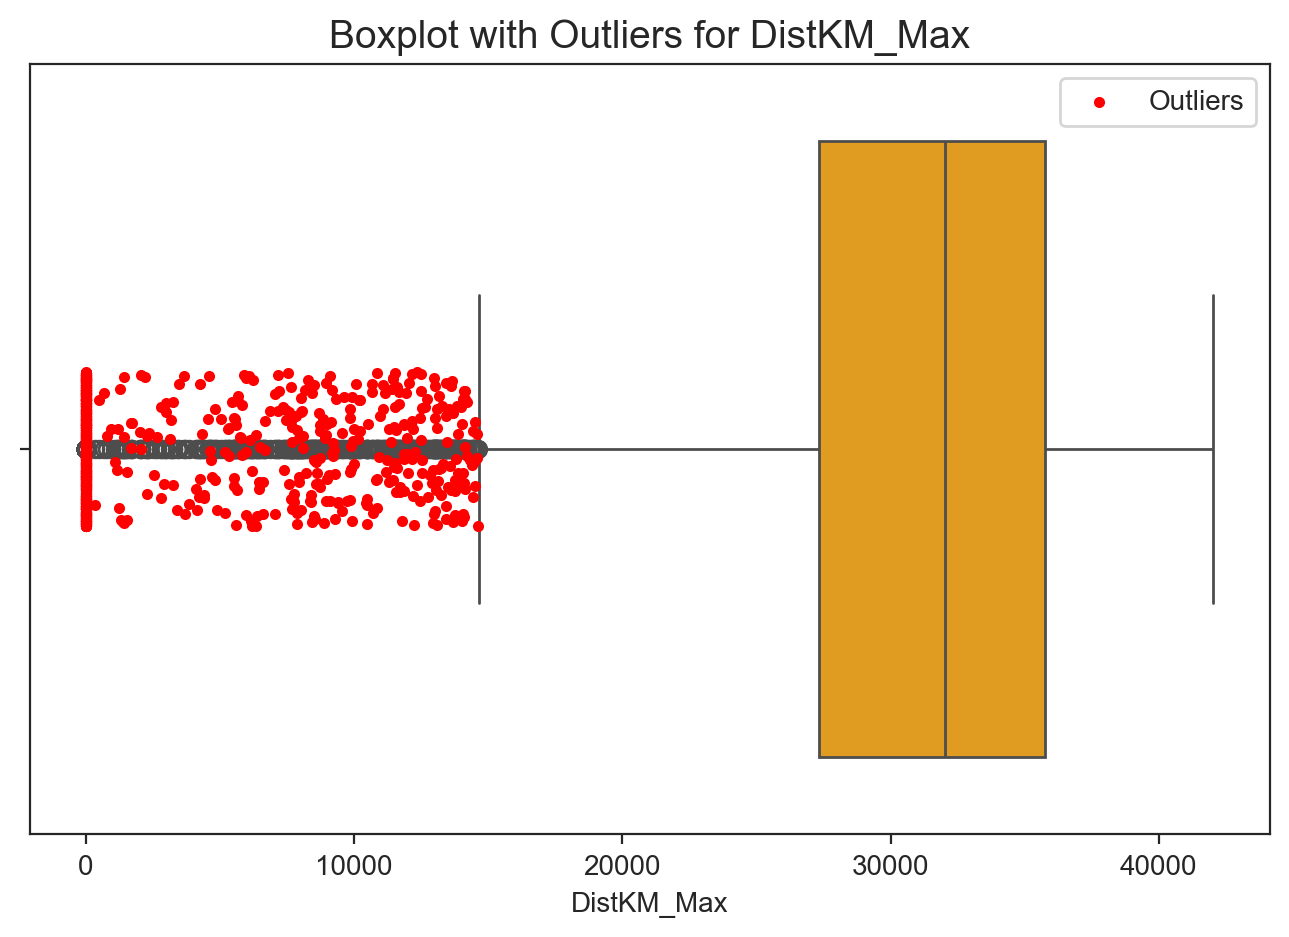

Column: PtsAcc_Sum - Number of Outliers: 0
Column: PtsAcc_Sum - % of Outliers: 0.00%



C:\Users\Francisco Martins\AppData\Local\Temp\ipykernel_15872\2753299276.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


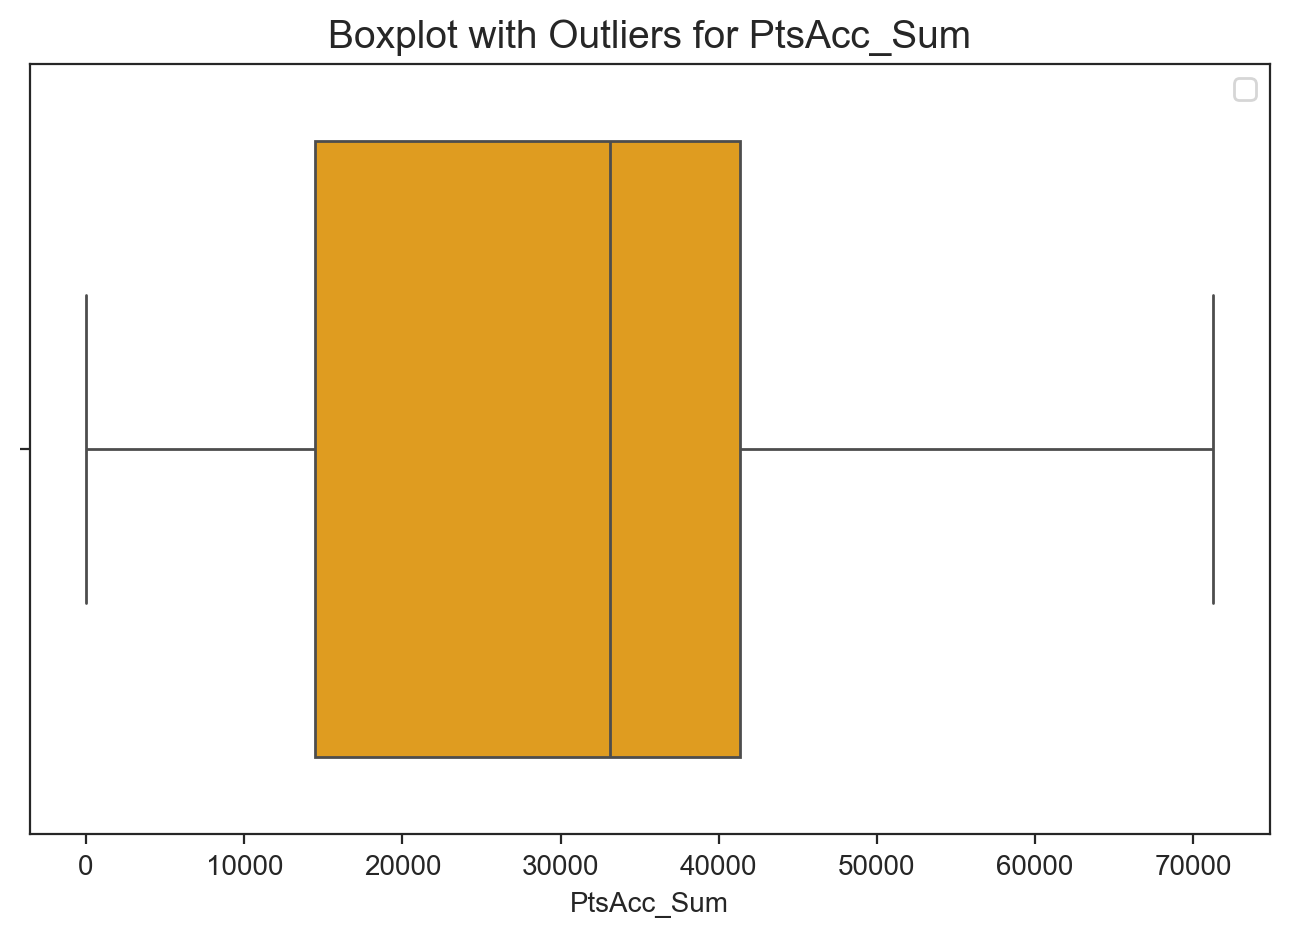

Column: PtsAcc_Mean - Number of Outliers: 0
Column: PtsAcc_Mean - % of Outliers: 0.00%



C:\Users\Francisco Martins\AppData\Local\Temp\ipykernel_15872\2753299276.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


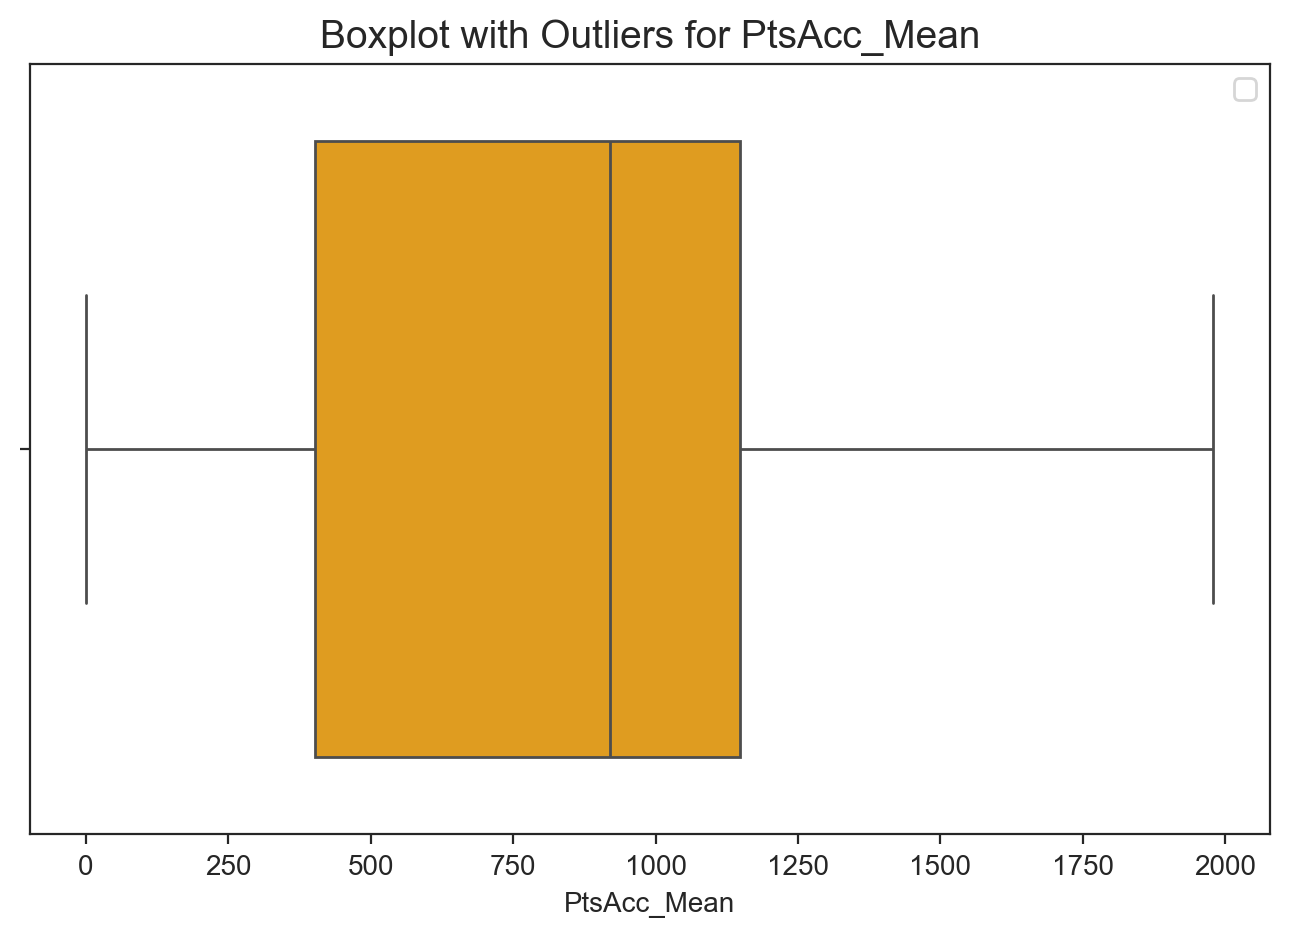

Column: PtsRed_Sum - Number of Outliers: 190
Column: PtsRed_Sum - % of Outliers: 1.15%



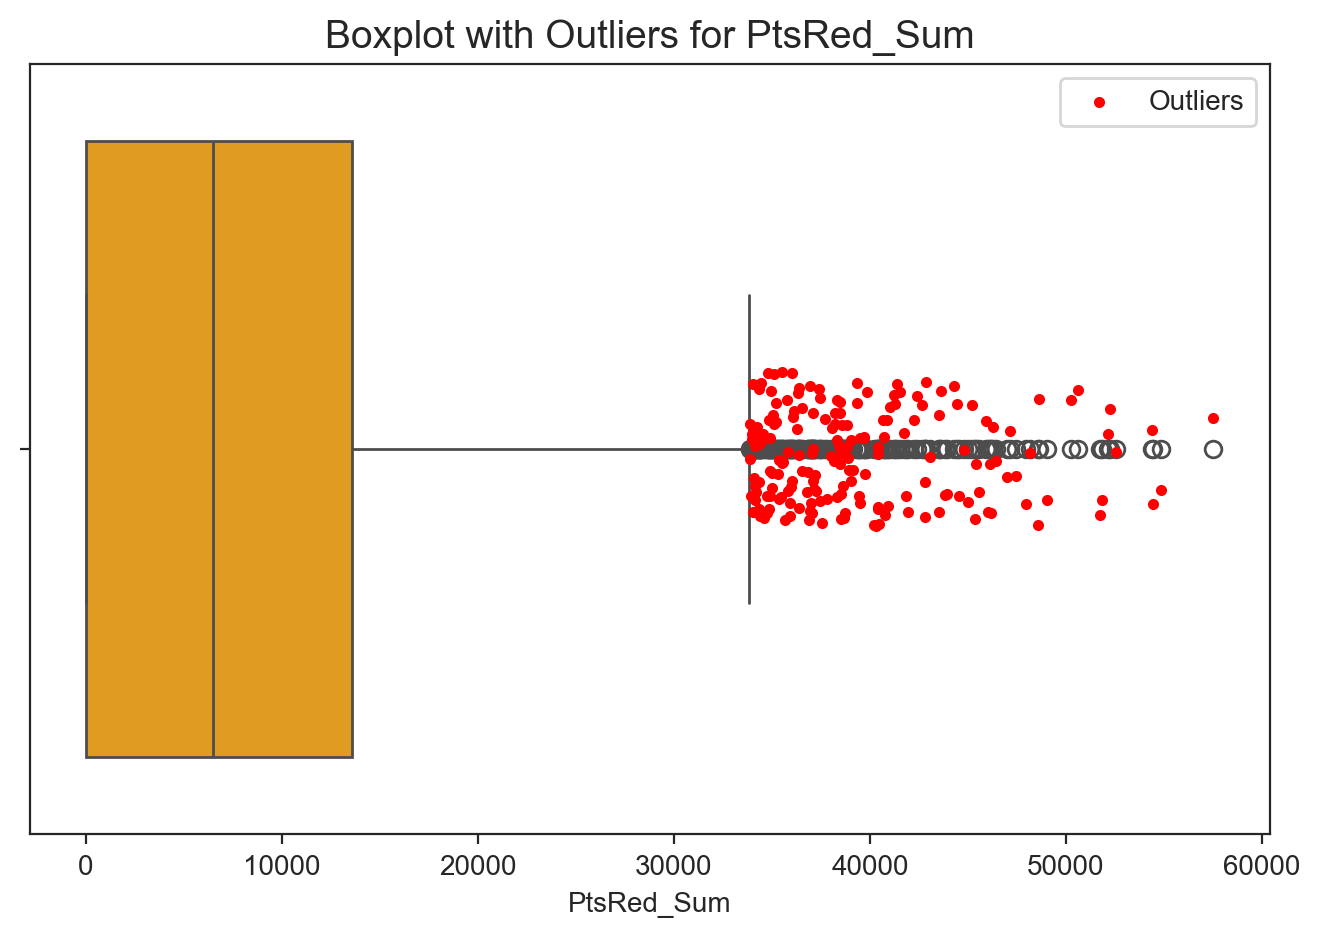

Column: PtsRed_Mean - Number of Outliers: 190
Column: PtsRed_Mean - % of Outliers: 1.15%



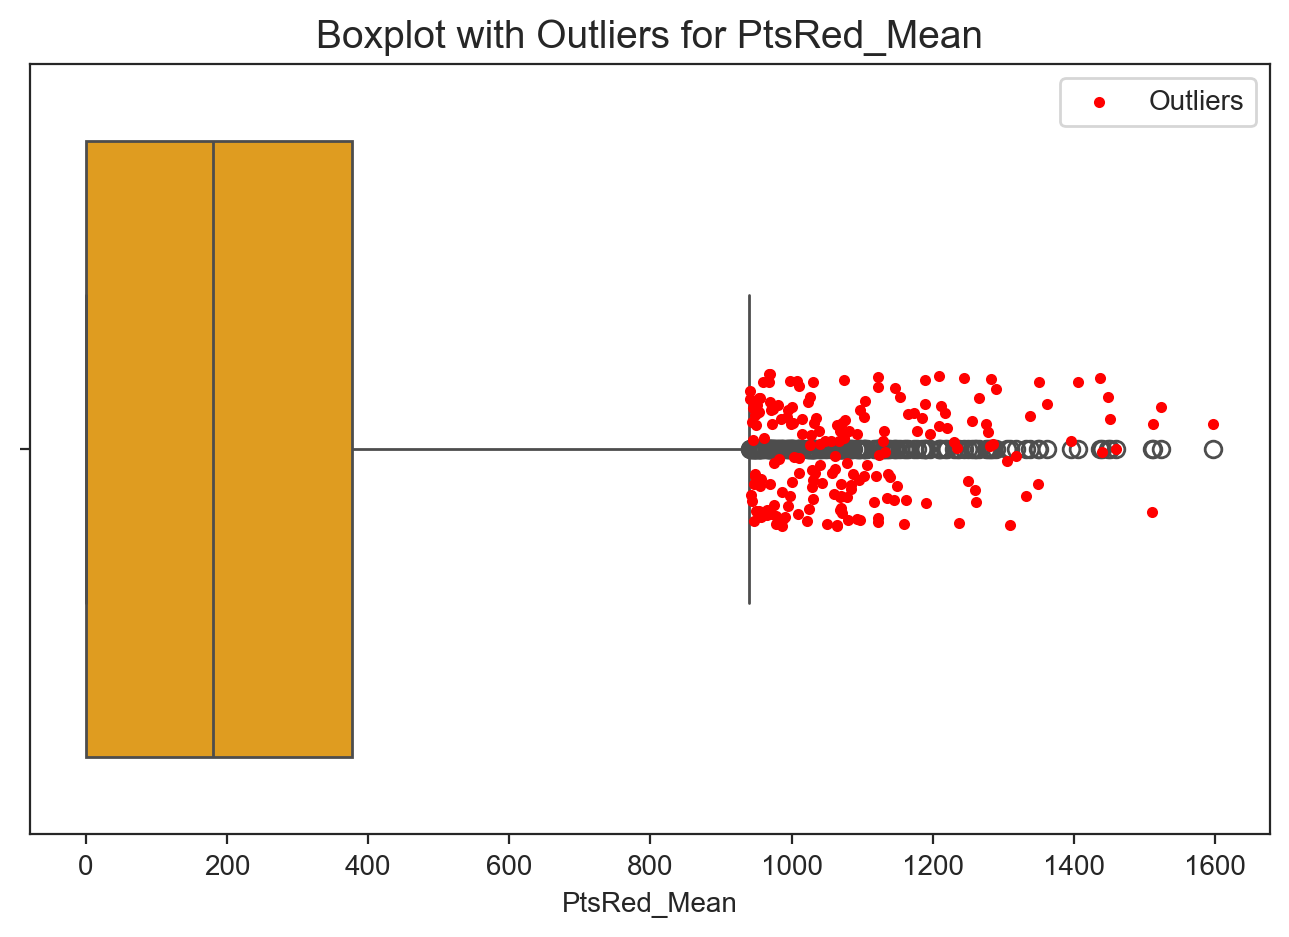

Column: CostPts_Sum - Number of Outliers: 187
Column: CostPts_Sum - % of Outliers: 1.13%



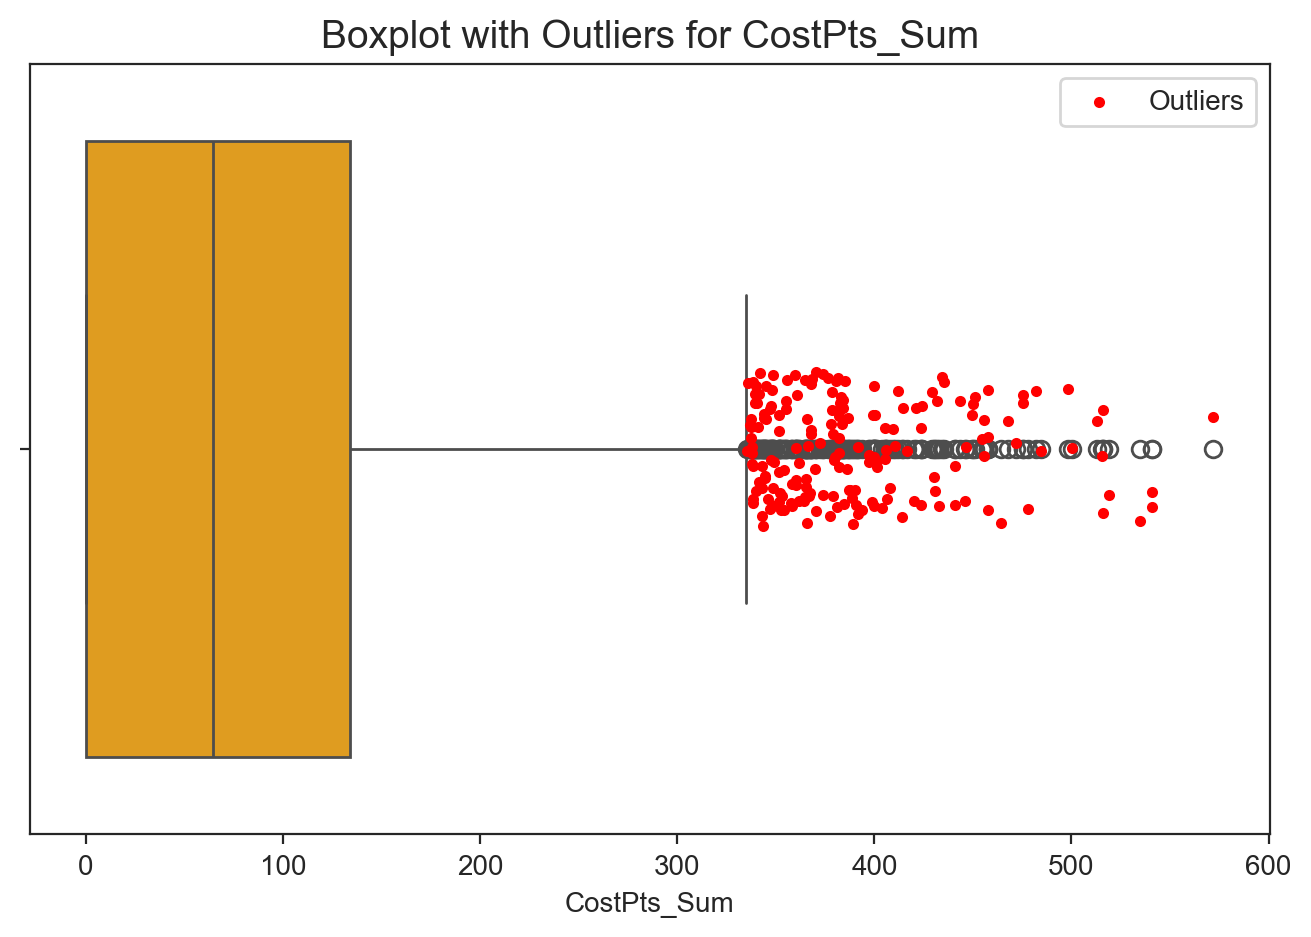

Column: CostPts_Mean - Number of Outliers: 187
Column: CostPts_Mean - % of Outliers: 1.13%



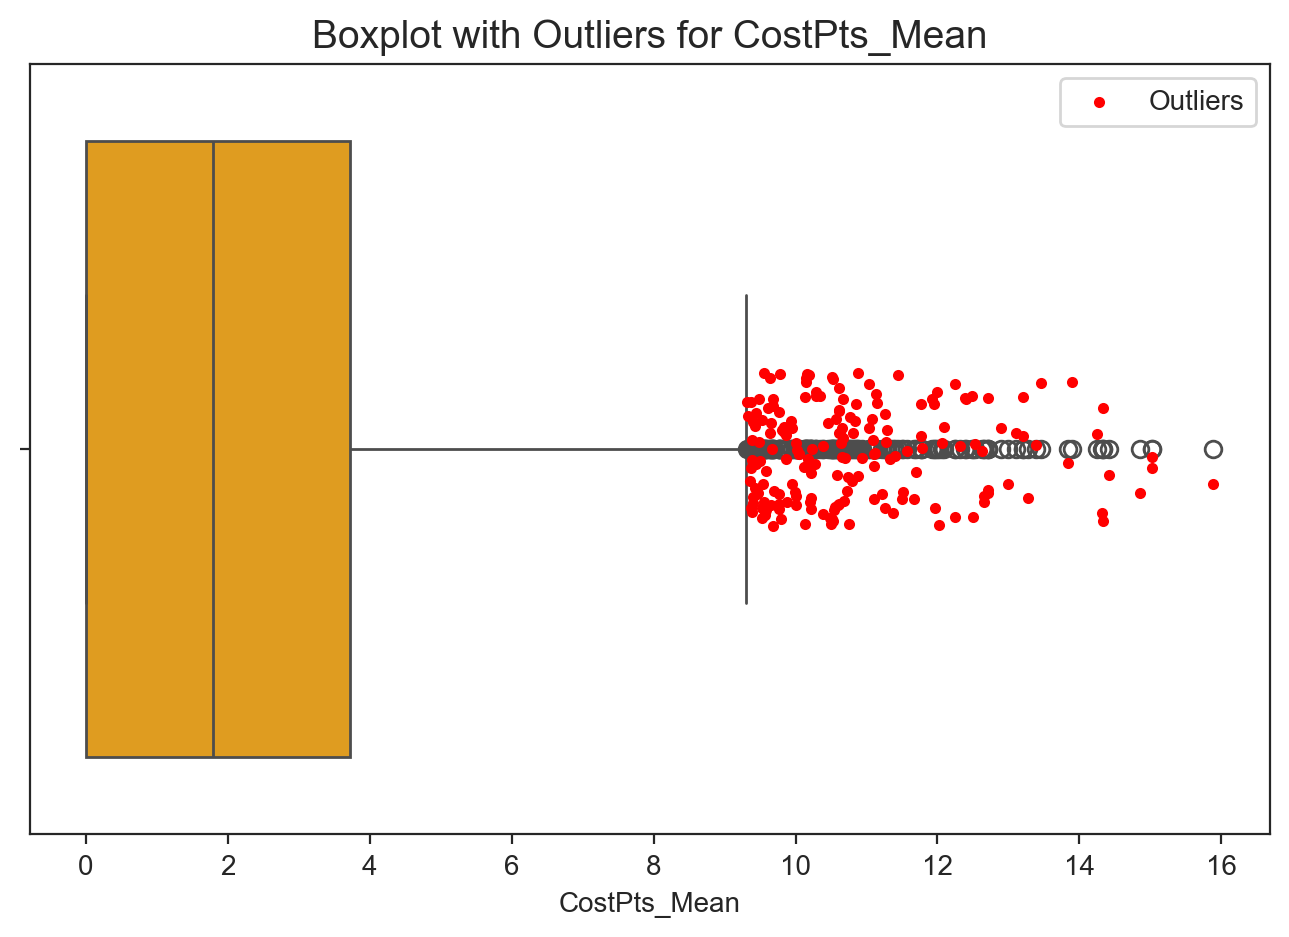

Column: PointsEfficiency - Number of Outliers: 408
Column: PointsEfficiency - % of Outliers: 2.46%



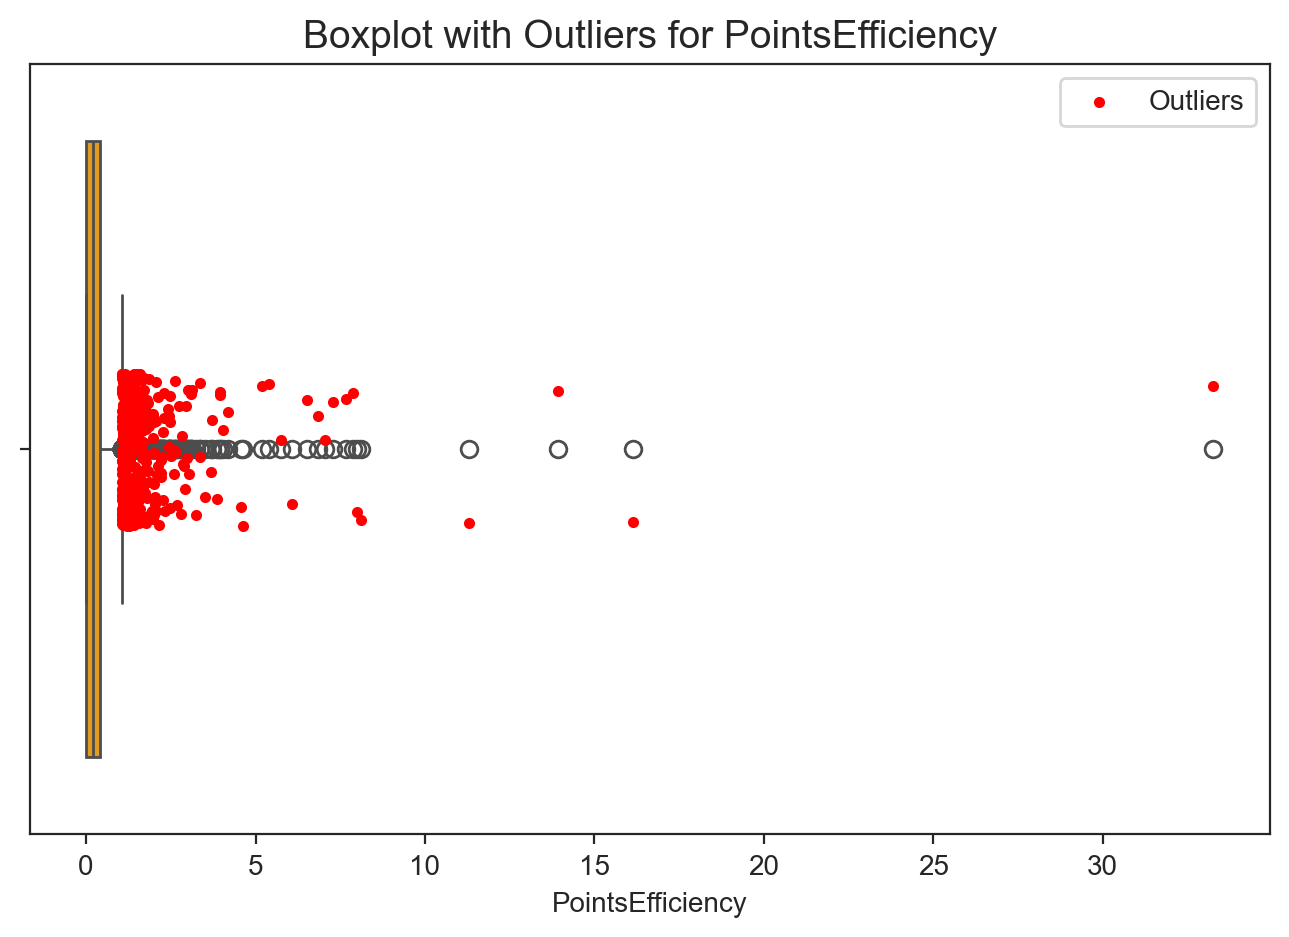

Column: DistPerFlight - Number of Outliers: 1943
Column: DistPerFlight - % of Outliers: 11.72%



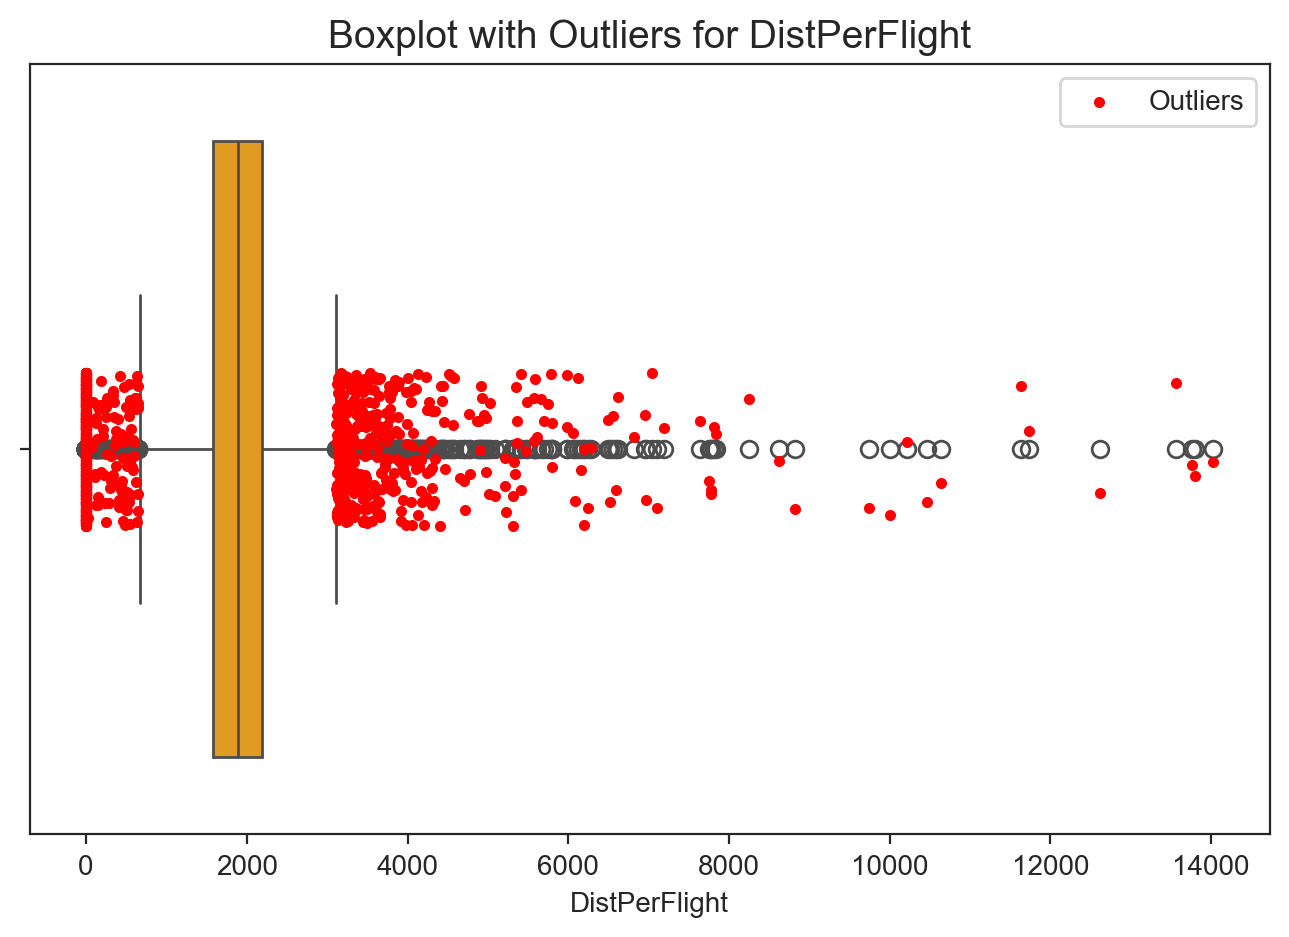

,Column,Num_Outliers,Pct_Outliers
0,Customer Lifetime Value,1460,8.808978
1,Flights_Max,1620,9.774345
2,FlightsComp_Sum,18,0.108604
3,FlightsComp_Mean,18,0.108604
4,DistKM_Max,1808,10.908652
5,PtsRed_Sum,190,1.146374
6,PtsRed_Mean,190,1.146374
7,CostPts_Sum,187,1.128273
8,CostPts_Mean,187,1.128273
9,PointsEfficiency,408,2.461687


In [696]:
detect_outliers_iqr(df_agg_merged[df_agg_merged_out], 0.001)

<h3> PointsEfficiency

In [697]:
df_agg_merged.loc[df_agg_merged['PointsEfficiency']> 1, ['Loyalty#', 'Customer Lifetime Value', 'Income', 'Days_sub', 'Flights_Sum', 'DistKM_Sum', 'PtsAcc_Sum', 'PtsRed_Sum', 'PointsEfficiency']]

,Loyalty#,Customer Lifetime Value,Income,Days_sub,Flights_Sum,DistKM_Sum,PtsAcc_Sum,PtsRed_Sum,PointsEfficiency
74,501704,3974.86,0,2067,198.0,376675.4,37657.84,45023.5,1.195594
78,688524,3980.42,98333,2105,132.0,268011.7,26796.27,40394.0,1.507449
86,984713,3997.48,0,148,15.0,27142.0,2713.00,4552.0,1.677847
102,890753,4025.10,0,484,92.0,94183.1,9411.61,11561.5,1.228430
150,355331,4145.02,0,2002,269.0,328911.6,32883.06,34855.7,1.059990
...,...,...,...,...,...,...,...,...,...
16499,149841,32864.40,90783,243,38.0,118441.0,11841.00,12127.0,1.024153
16507,737604,33473.35,33190,2368,115.0,247871.5,24781.75,28511.7,1.150512
16549,753864,40224.01,48587,171,9.0,17427.0,1741.00,3703.0,2.126939
16550,969719,40235.97,77143,245,5.0,11768.6,1176.46,8295.4,7.051153


We are going to remove the observations where pointsefficiency is higher than 1, because having more points redeemed than accumulated is not normal. Maybe its not a mistake because customers can have points accumulated from outside of the time period of this dataset, but we will remove them to reduce potencial noise.

In [698]:
df_agg_merged = df_agg_merged[df_agg_merged['PointsEfficiency'] <= 1]

Column: PointsEfficiency - Number of Outliers: 0
Column: PointsEfficiency - % of Outliers: 0.00%



C:\Users\Francisco Martins\AppData\Local\Temp\ipykernel_15872\2753299276.py:33: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


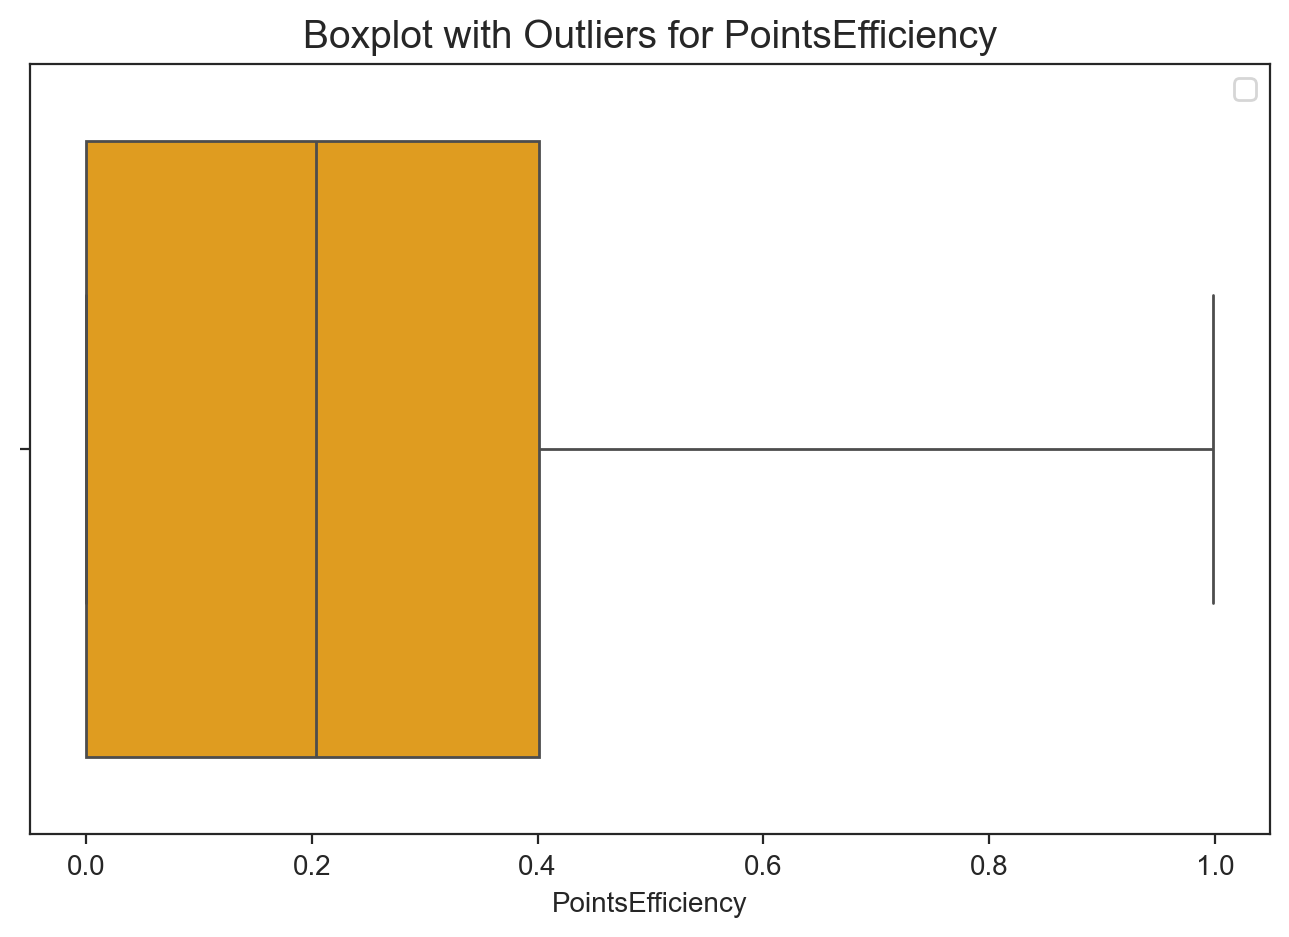

,Column,Num_Outliers,Pct_Outliers


In [699]:
pointsefficiency = ['PointsEfficiency']
detect_outliers_iqr(df_agg_merged[pointsefficiency], 0.001)

<h3>DistPerFlight

In [700]:
df_agg_merged.loc[df_agg_merged['DistPerFlight']>8000, ['Loyalty#', 'Flights_Sum', 'DistKM_Sum', 'DistPerFlight']]

,Loyalty#,Flights_Sum,DistKM_Sum,DistPerFlight
2074,443557,2.0,23267.0,11633.50
2254,295795,2.0,19998.0,9999.00
6612,353308,4.0,32980.0,8245.00
7539,305572,1.0,10463.0,10463.00
8428,472921,3.0,25851.0,8617.00
9591,840659,4.0,46958.0,11739.50
11064,278059,2.0,21275.0,10637.50
11346,731254,1.0,10216.0,10216.00
12286,808341,2.0,28057.0,14028.50
12759,430221,6.0,52914.0,8819.00


These values are high and can affect clustering algorithms. But these clients travel a lot and this means that they are valuable customers to AIAI, therefore, we will try to mitigate the impact by a log transformation or robust scalling 

Log-Transform

In [701]:
df_agg_merged["DistPerFlight_log"] = np.log1p(df_agg_merged["DistPerFlight"])

<h3>Customer Lifetime Value

In [702]:
df_agg_merged.loc[df_agg_merged['Customer Lifetime Value']>50000, ['Customer Lifetime Value', 'Income', 'Days_sub', 'Flights_Sum', 'DistKM_Sum', 'PtsAcc_Sum', 'PtsRed_Sum', 'PointsEfficiency']]

,Customer Lifetime Value,Income,Days_sub,Flights_Sum,DistKM_Sum,PtsAcc_Sum,PtsRed_Sum,PointsEfficiency
4065,51016.07,25167,902,167.0,491965.9,49188.39,8905.3,0.181045
4066,51426.25,84650,244,26.0,71013.0,7100.00,0.0,0.000000
4067,52811.49,0,372,49.0,88399.0,8838.00,4225.0,0.478049
4068,55277.45,40740,68,12.0,4104.0,410.00,0.0,0.000000
4069,56675.94,77237,1366,239.0,469220.7,46912.27,35839.3,0.763964
4070,57520.50,48367,331,212.0,414025.5,41394.35,10106.2,0.244144
4071,58166.55,61321,1025,147.0,250238.3,25016.63,9132.0,0.365037
4072,58753.88,24964,851,37.0,66859.0,6685.00,0.0,0.000000
4073,61850.19,0,2000,137.0,231506.5,23146.75,0.0,0.000000
4074,66025.75,33481,546,150.0,231571.6,23150.86,0.0,0.000000


These observations represent high-value customers, we will take the same approach we took with DistPerFlight.

LogTransform

In [703]:
df_agg_merged["Customer_Lifetime_Value_log"] = np.log1p(df_agg_merged["Customer Lifetime Value"])

<h3>Customers with Flights_Sum == 0 and customer lifetime value > 0

In [704]:
df_agg_merged.loc[(df_agg_merged['Flights_Sum'] == 0) & (df_agg_merged['Customer Lifetime Value'] > 0),
                    ['Customer Lifetime Value', 'Income', 'Days_sub', 'Flights_Sum', 'Flights_Mean', 'DistKM_Sum', 'DistKM_Mean', 'PtsAcc_Sum', 'PtsAcc_Mean', 'PtsRed_Sum', 'PtsRed_Mean']].shape

(1469, 11)

In [705]:
df_agg_merged.loc[(df_agg_merged['Flights_Sum'] == 0) & (df_agg_merged['Customer Lifetime Value'] > 0),
                    ['Customer Lifetime Value', 'Income', 'Days_sub', 'Flights_Sum', 'Flights_Mean', 'DistKM_Sum', 'DistKM_Mean', 'PtsAcc_Sum', 'PtsAcc_Mean', 'PtsRed_Sum', 'PtsRed_Mean']].sample(10)

,Customer Lifetime Value,Income,Days_sub,Flights_Sum,Flights_Mean,DistKM_Sum,DistKM_Mean,PtsAcc_Sum,PtsAcc_Mean,PtsRed_Sum,PtsRed_Mean
4935,3359.29,16891,2196,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
13097,4983.90,28726,242,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10247,2413.89,0,243,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8870,12522.54,44341,2223,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3764,20604.02,0,87,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11237,2628.47,99961,616,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
16545,39033.08,0,2246,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
11473,2693.61,0,1732,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1484,5926.73,23091,243,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
572,4791.08,29111,244,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


This doesn't mean that these are errors, this just means that these customers haven't done any flight since joining the loyalty program. To confirm that, we can see that most of them have low number of Days_sub.

## Scaling

MinMax ou Standard???

In [706]:
merged_agg_metric = ['Income','Customer_Lifetime_Value_log','Days_sub', 'Flights_Sum',
       'Flights_Mean', 'Flights_Max', 'FlightsComp_Sum', 'FlightsComp_Mean',
       'DistKM_Sum', 'DistKM_Mean', 'DistKM_Max', 'PtsAcc_Sum', 'PtsAcc_Mean',
       'PtsRed_Sum', 'PtsRed_Mean', 'CostPts_Sum', 'CostPts_Mean',
       'PointsEfficiency', 'DistPerFlight_log']

In [707]:
# Initialize MinMaxScaler
scaler = MinMaxScaler()

# Fit the scaler on the data and transform it
df_agg_scaled = scaler.fit_transform(df_agg_merged[merged_agg_metric])

# Convert scaled data into a DataFrame with the same index as the original DataFrame
df_agg_scaled_df = pd.DataFrame(df_agg_scaled, columns=merged_agg_metric, index=df_agg_merged.index)

# Select the non-metric features from the original data
non_metric_features_agg = df_agg_merged.drop(columns=merged_agg_metric)

# Combine the scaled metric features with the non-metric features (ensure no new rows are added)
df_combined_agg = pd.concat([df_agg_scaled_df, non_metric_features_agg], axis=1)

df_combined_agg.sample(5)

,Income,Customer_Lifetime_Value_log,Days_sub,Flights_Sum,Flights_Mean,Flights_Max,FlightsComp_Sum,FlightsComp_Mean,DistKM_Sum,DistKM_Mean,...,Loyalty#,Province or State,City,Gender,Education,Marital Status,LoyaltyStatus,Customer Lifetime Value,EnrollmentType,DistPerFlight
6123,0.617967,0.252255,0.803245,0.422741,0.422741,0.761905,0.344538,0.344538,0.533450,0.533450,...,947099,British Columbia,Vancouver,male,Bachelor,Married,Nova,4928.40,Standard,2622.107586
14672,0.246707,0.377254,0.834888,0.766764,0.766764,0.809524,0.445378,0.445378,0.705707,0.705707,...,996616,New Brunswick,Moncton,female,Bachelor,Married,Star,7907.13,Standard,1912.464259
15141,0.305308,0.407837,0.335497,0.632653,0.632653,0.857143,0.378151,0.378151,0.569566,0.569566,...,426384,Quebec,Montreal,female,Bachelor,Single,Star,8876.67,Standard,1870.722581
131,0.000000,0.204132,0.223529,0.478134,0.478134,0.666667,0.151261,0.151261,0.377569,0.377569,...,119488,Quebec,Tremblant,female,College,Single,Star,4108.26,Standard,1640.879878
3729,0.705164,0.614487,0.027181,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,905161,British Columbia,Dawson Creek,female,Bachelor,Divorced,Aurora,19393.21,Standard,0.000000


In [708]:
# Initialize MinMaxScaler
scaler2 = StandardScaler()

# Fit the scaler on the data and transform it
df_agg_scaled = scaler2.fit_transform(df_agg_merged[merged_agg_metric])

# Convert scaled data into a DataFrame with the same index as the original DataFrame
df_agg_scaled_df = pd.DataFrame(df_agg_scaled, columns=merged_agg_metric, index=df_agg_merged.index)

# Select the non-metric features from the original data
non_metric_features_agg = df_agg_merged.drop(columns=merged_agg_metric)

# Combine the scaled metric features with the non-metric features (ensure no new rows are added)
df_combined_agg2 = pd.concat([df_agg_scaled_df, non_metric_features_agg], axis=1)

df_combined_agg2.sample(5)

,Income,Customer_Lifetime_Value_log,Days_sub,Flights_Sum,Flights_Mean,Flights_Max,FlightsComp_Sum,FlightsComp_Mean,DistKM_Sum,DistKM_Mean,...,Loyalty#,Province or State,City,Gender,Education,Marital Status,LoyaltyStatus,Customer Lifetime Value,EnrollmentType,DistPerFlight
5941,-0.815481,-0.437094,-1.182206,-1.810303,-1.810303,-2.670507,-1.527040,-1.527040,-1.796019,-1.796019,...,641827,British Columbia,Vancouver,male,High School or Below,Married,Nova,4726.87,Standard,0.000000
9072,0.761252,1.275513,0.470233,1.115282,1.115282,0.630395,1.124657,1.124657,0.827330,0.827330,...,506572,Ontario,Toronto,female,Bachelor,Married,Nova,14435.67,Standard,1752.390947
9174,1.976355,1.403877,0.595253,0.549428,0.549428,0.080244,-0.628159,-0.628159,0.493142,0.493142,...,328446,Ontario,Trenton,male,Bachelor,Divorced,Nova,15695.54,Standard,1895.839286
332,0.119327,-0.520243,1.334502,0.669822,0.669822,0.630395,0.405553,0.405553,0.972234,0.972234,...,565133,Ontario,Toronto,male,Bachelor,Divorced,Star,4477.45,Standard,2181.322330
6580,0.215000,-0.214832,0.187579,-0.690635,-0.690635,0.263628,-0.403439,-0.403439,-0.442134,-0.442134,...,760975,British Columbia,Vancouver,male,Bachelor,Married,Nova,5463.91,Standard,2363.089247


## Encoding of categorical features

We will encode the categorical features using the OHE.

In [709]:
df_combined_agg.columns

Index(['Income', 'Customer_Lifetime_Value_log', 'Days_sub', 'Flights_Sum',
       'Flights_Mean', 'Flights_Max', 'FlightsComp_Sum', 'FlightsComp_Mean',
       'DistKM_Sum', 'DistKM_Mean', 'DistKM_Max', 'PtsAcc_Sum', 'PtsAcc_Mean',
       'PtsRed_Sum', 'PtsRed_Mean', 'CostPts_Sum', 'CostPts_Mean',
       'PointsEfficiency', 'DistPerFlight_log', 'Loyalty#',
       'Province or State', 'City', 'Gender', 'Education', 'Marital Status',
       'LoyaltyStatus', 'Customer Lifetime Value', 'EnrollmentType',
       'DistPerFlight'],
      dtype='object')

In [710]:
non_metric_features_agg = ['City',	'Province or State',
                       		'Gender',	'Education',	'Marital Status',
                        	'LoyaltyStatus',	'EnrollmentType']

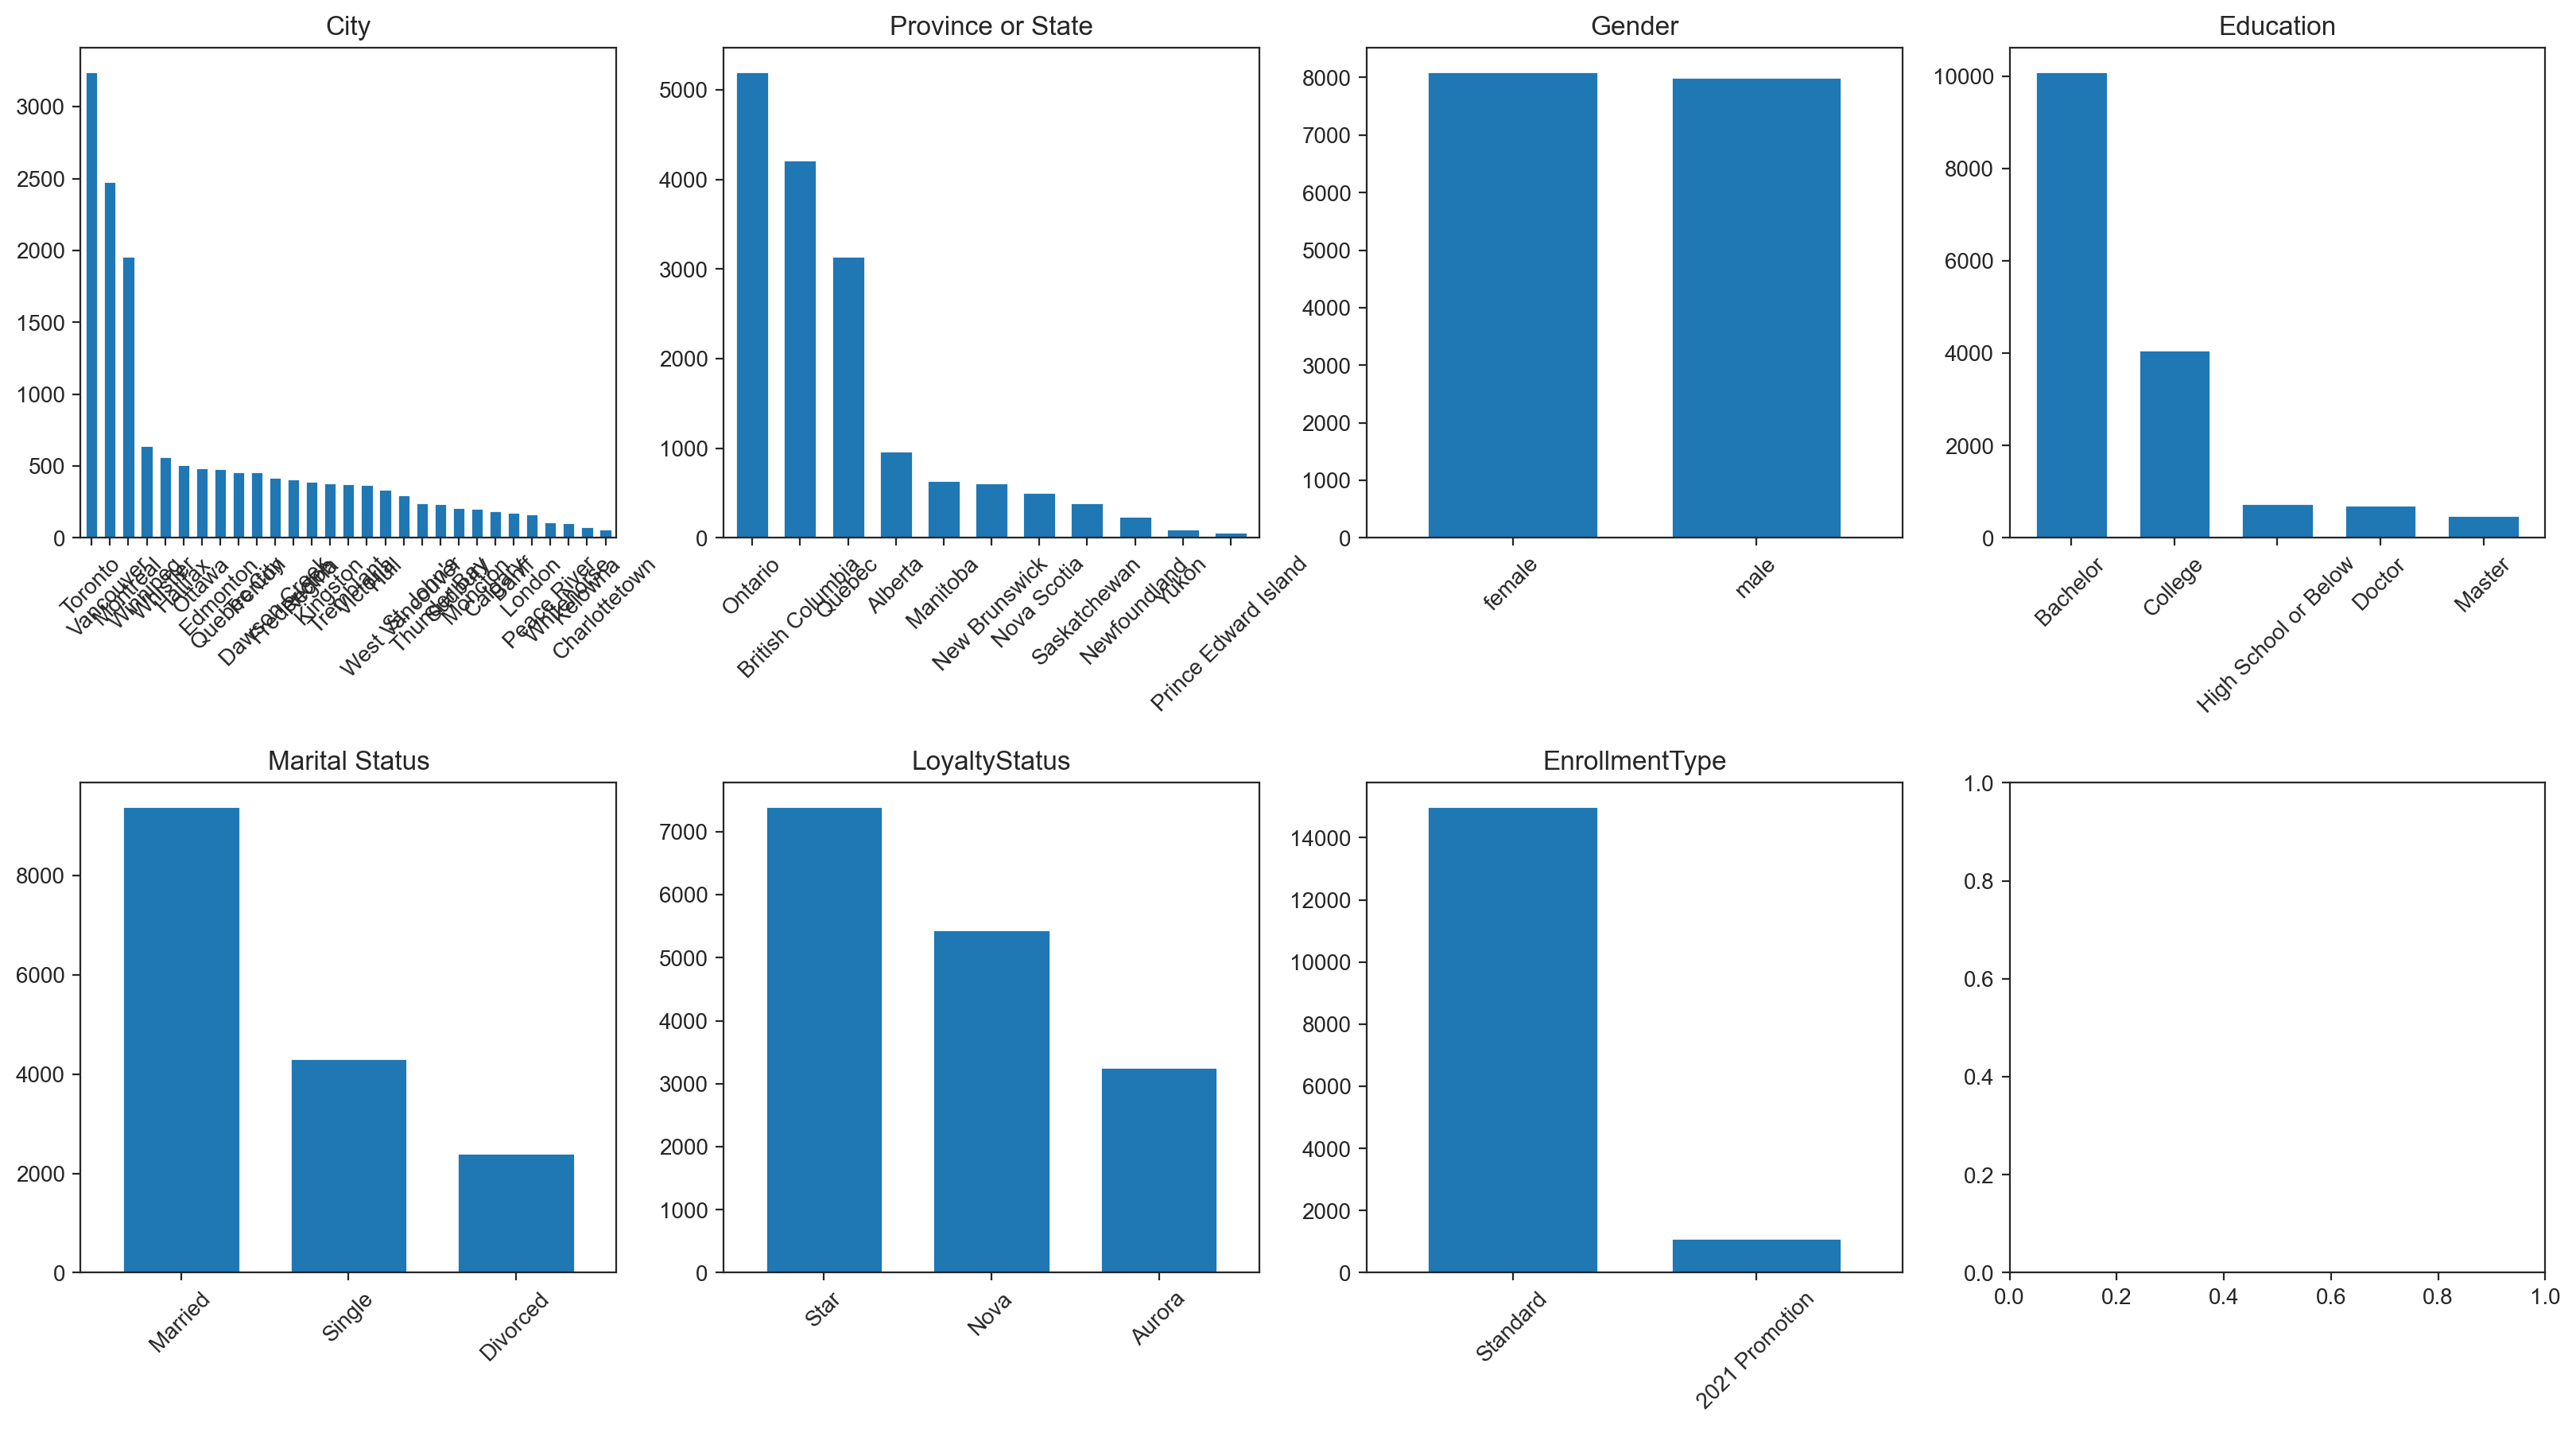

In [711]:
fig, axes = plt.subplots(
    2,
    ceil(len(non_metric_features_agg) / 2),
    figsize=(20,10))

for ax, feat in zip(axes.flatten(), non_metric_features_agg):
    df_combined_agg[feat].value_counts().plot.bar(ax=ax, width=.7)
    ax.set_title(feat)
    ax.set_xlabel(None)
    ax.set_ylabel(None) 
    ax.tick_params(axis='x', rotation=45)

plt.subplots_adjust(hspace=0.5)
plt.show()

We are going to use the One hot Encondig for the features "Gender", "Marital Status" and "Enrollment Type". For "Education" since we can order them from the least level of studies to the highest, we are using the Ordinal Enconding. Due to its high cardinality, for "Province or State" and "City" we are using the Frequency Enconding.

In [712]:
df_ohc = df_combined_agg.copy()

categorical_features = ['Gender','Marital Status', 'EnrollmentType']

ohc = OneHotEncoder(sparse_output=False)

ohc_feat = ohc.fit_transform(df_ohc[categorical_features])

ohc_feat_names = ohc.get_feature_names_out(categorical_features)

ohc_df = pd.DataFrame(ohc_feat, index=df_ohc.index, columns=ohc_feat_names)

df_ohc = pd.concat([df_ohc, ohc_df], axis=1)

df_final = df_ohc.copy()
# Dropping categorical Variables
df_final = df_final.drop(columns=['Gender','Marital Status', 'EnrollmentType'])

In [713]:
df_final = df_final.set_index('Loyalty#')

In [714]:
education_order = [
    'High School or Below',
    'College',
    'Bachelor',
    'Master',
    'Doctor'
]

encoder_edu = OrdinalEncoder(categories=[education_order])

df_final['Education_Encoded'] = encoder_edu.fit_transform(
    df_final[['Education']]
)

df_final = df_final.drop(columns=['Education'])


In [715]:
# Proporção (0–1). Se quiser em %, multiplicar por 100 (ver abaixo).
province_share = df_final['Province or State'].value_counts(normalize=True)
df_final['Province_FE'] = df_final['Province or State'].map(province_share)

city_share = df_final['City'].value_counts(normalize=True)
df_final['City_FE'] = df_final['City'].map(city_share)

# (opcional) se quiser em percentagem 0–100:
# df_final['Province_FE'] *= 100
# df_final['City_FE'] *= 100

df_final = df_final.drop(columns=['Province or State', 'City'])

df_final[['Province_FE', 'City_FE']].head()


,Province_FE,City_FE
Loyalty#,,
480934,0.322971,0.201353
549612,0.060002,0.030032
429460,0.261976,0.153884
608370,0.322971,0.201353
530508,0.194899,0.021221


## DBSCAN Multivariate Outliers ???

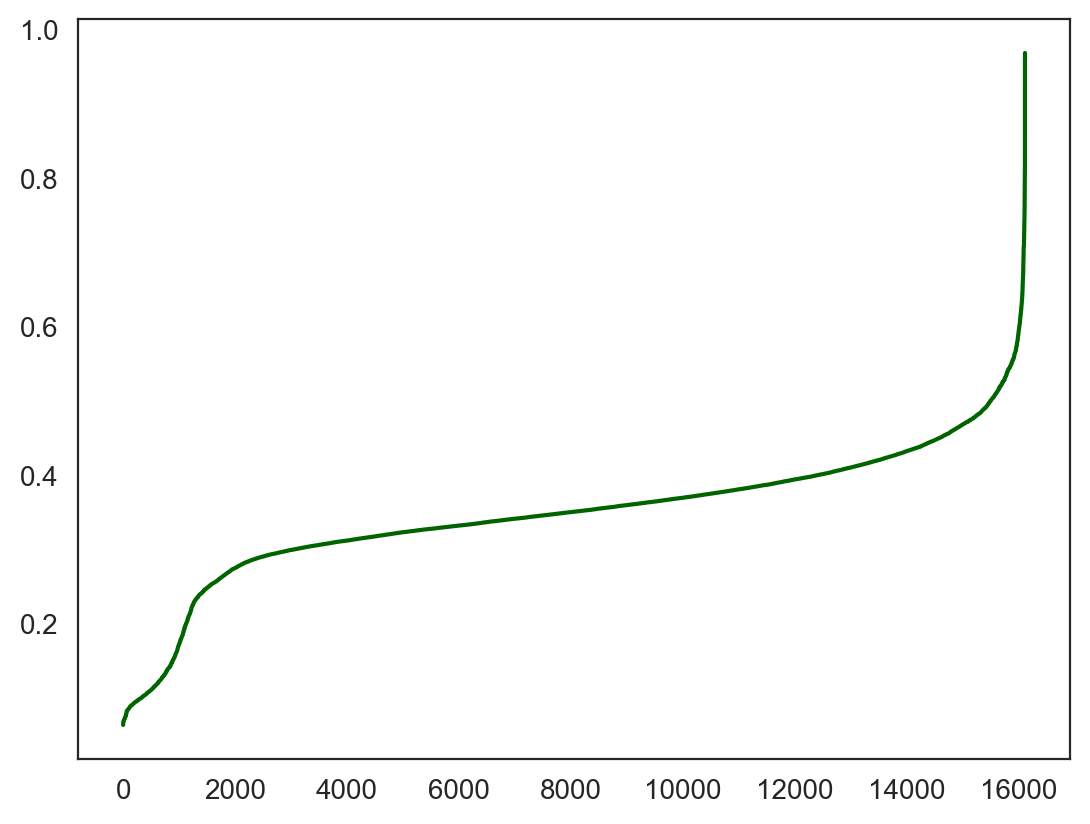

In [716]:
# K-distance graph to find out the right epsilon value
sns.set_style("white")
neigh = NearestNeighbors(n_neighbors=47)
neigh.fit(df_final[merged_agg_metric])
distances, _ = neigh.kneighbors(df_final[merged_agg_metric])
distances = np.sort(distances[:, -1])
plt.plot(distances, color='darkgreen')
plt.show()

## Feature Selection

In [717]:
df_final = df_final.drop('Customer Lifetime Value', axis=1)
df_final = df_final.drop('DistPerFlight', axis=1)

**Checking for multiculinearity**

We will indentify pairs of features that are highly correlated. First, we will define a treshold of |0.8|.



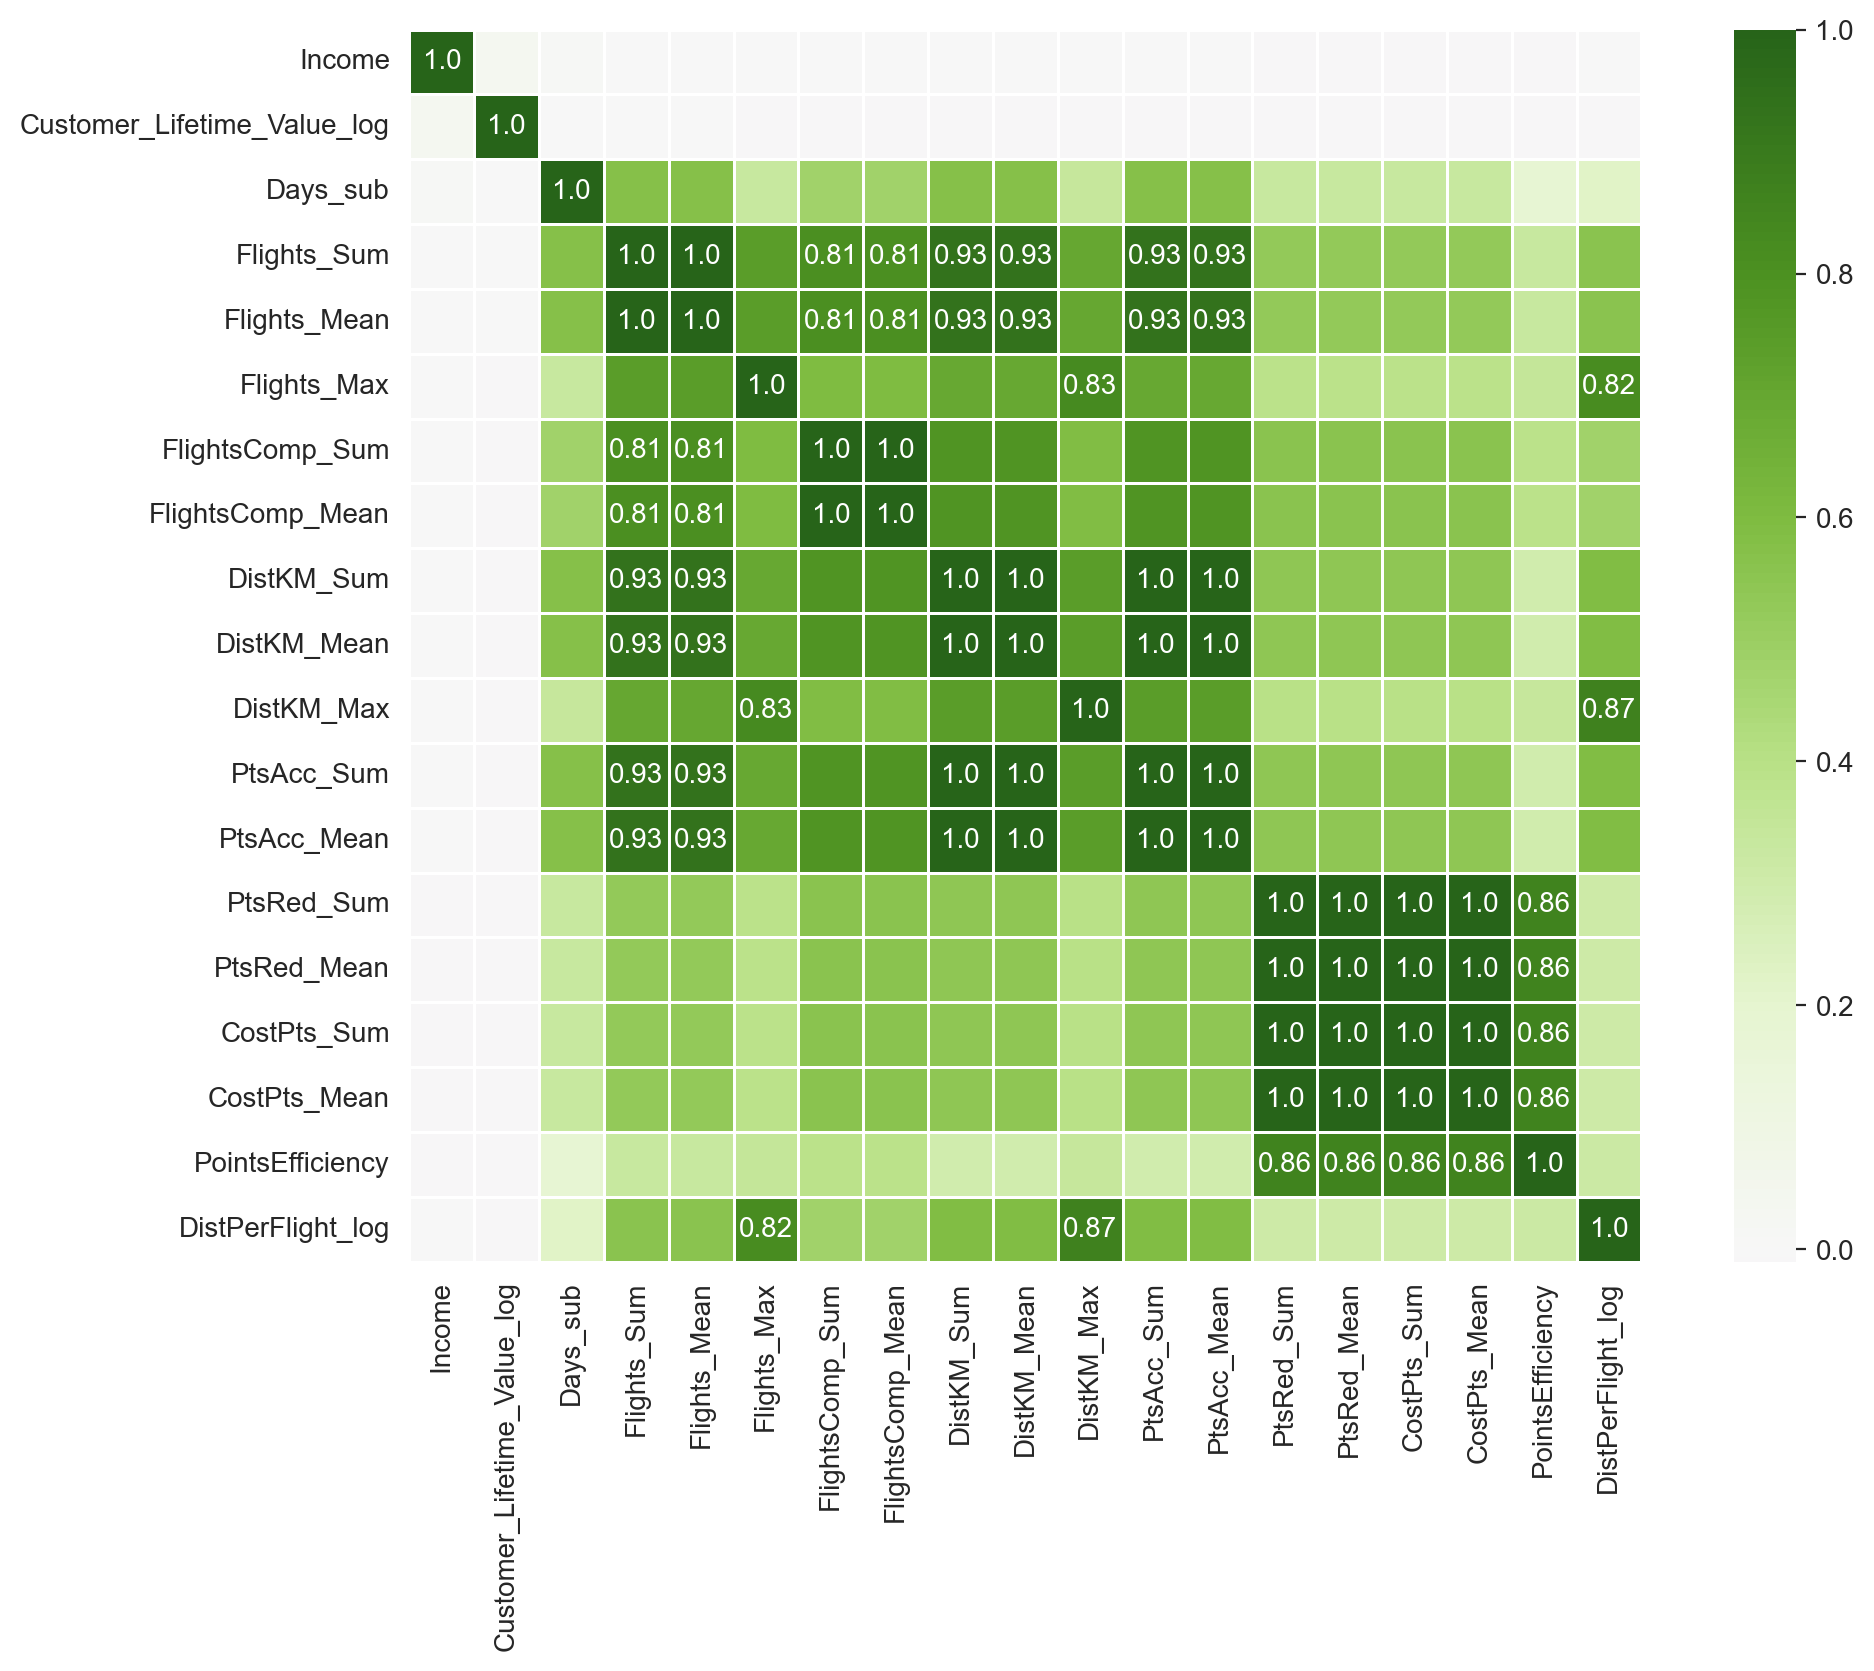

In [718]:
plt.figure(figsize=(12,8))
corr = df_final[merged_agg_metric].corr()
corr = corr.round(2)

sns.heatmap(
    corr,
    center = 0,
    cmap='PiYG',
    annot=np.where(np.absolute(corr) >= 0.8, corr.values, np.full(corr.values.shape, "")),
    fmt='s',
    square=True,
    linewidths=.5,
)
plt.show()

In [719]:
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

corr_pairs = corr.where(mask).stack().reset_index()
corr_pairs.columns = ['Feature1', 'Feature2', 'Correlation']

high_corr_pairs = corr_pairs[corr_pairs['Correlation'] > 0.8]

high_corr_pairs

,Feature1,Feature2,Correlation
51,Flights_Sum,Flights_Mean,1.00
53,Flights_Sum,FlightsComp_Sum,0.81
54,Flights_Sum,FlightsComp_Mean,0.81
55,Flights_Sum,DistKM_Sum,0.93
56,Flights_Sum,DistKM_Mean,0.93
58,Flights_Sum,PtsAcc_Sum,0.93
59,Flights_Sum,PtsAcc_Mean,0.93
67,Flights_Mean,FlightsComp_Sum,0.81
68,Flights_Mean,FlightsComp_Mean,0.81
69,Flights_Mean,DistKM_Sum,0.93


For the flights group of features, since thry're all high correlated, the one that makes more sence to keep is "FlightsSum".

For the Distance group of features, the same conclusion as for the previous one, we must keep "DistKM_Sum".

For the Points Accumulated group of features, same conclusion as the previous ones, we must kepp "PtsAcc_Sum".

For the Points Redeemed group of features, same conclusion as the previous ones, we must kepp "PtsRed_Sum".

For the Cost Points group of features, same conclusion as the previous ones, we must kepp "CostPts_Sum".

For the Companions Flights group of features, same conclusion as the previous ones, we must kepp "FlightsComp_Sum".


In [720]:
features_to_drop = [
    'Flights_Mean',
    'Flights_Max',
    'FlightsComp_Mean',
    'DistKM_Mean',
    'DistKM_Max',
    'PtsAcc_Mean',
    'PtsRed_Mean',
    'CostPts_Mean'
]

df_final = df_final.drop(columns=[col for col in features_to_drop if col in df_final.columns])
merged_agg_metric = [col for col in merged_agg_metric if col not in features_to_drop]
df_final.columns


Index(['Income', 'Customer_Lifetime_Value_log', 'Days_sub', 'Flights_Sum',
       'FlightsComp_Sum', 'DistKM_Sum', 'PtsAcc_Sum', 'PtsRed_Sum',
       'CostPts_Sum', 'PointsEfficiency', 'DistPerFlight_log', 'LoyaltyStatus',
       'Gender_female', 'Gender_male', 'Marital Status_Divorced',
       'Marital Status_Married', 'Marital Status_Single',
       'EnrollmentType_2021 Promotion', 'EnrollmentType_Standard',
       'Education_Encoded', 'Province_FE', 'City_FE'],
      dtype='object')

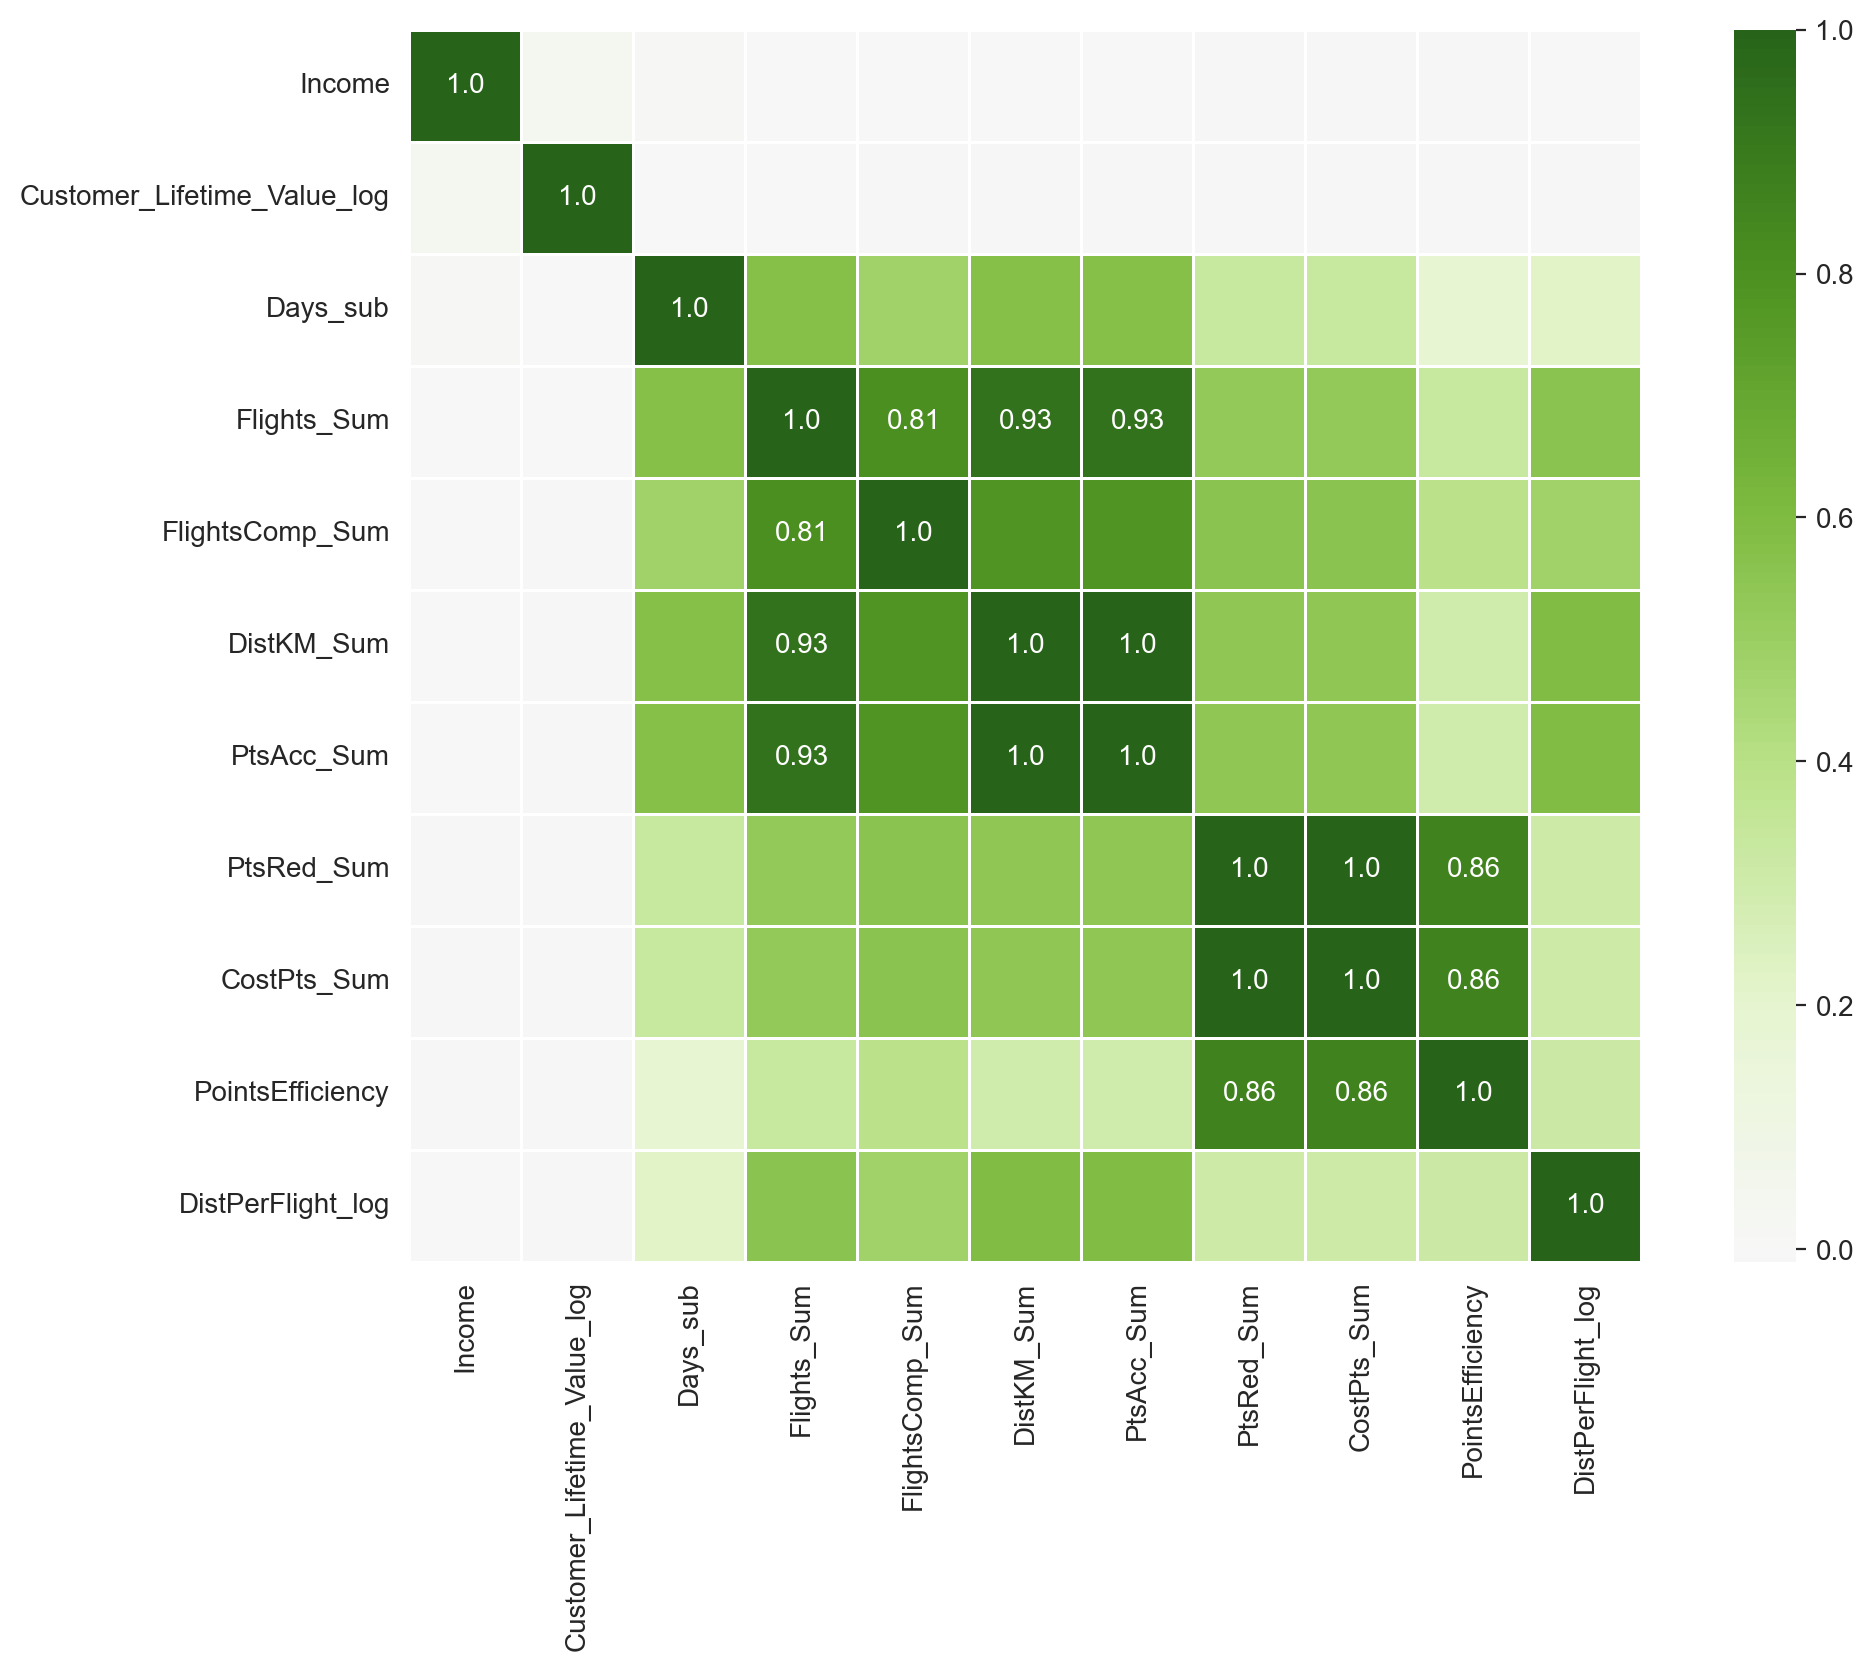

In [721]:
plt.figure(figsize=(12,8))
corr = df_final[merged_agg_metric].corr()
corr = corr.round(2)

sns.heatmap(
    corr,
    center = 0,
    cmap='PiYG',
    annot=np.where(np.absolute(corr) >= 0.8, corr.values, np.full(corr.values.shape, "")),
    fmt='s',
    square=True,
    linewidths=.5,
)
plt.show()

In [722]:
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

corr_pairs = corr.where(mask).stack().reset_index()
corr_pairs.columns = ['Feature1', 'Feature2', 'Correlation']

high_corr_pairs = corr_pairs[corr_pairs['Correlation'] > 0.8]

high_corr_pairs

,Feature1,Feature2,Correlation
27,Flights_Sum,FlightsComp_Sum,0.81
28,Flights_Sum,DistKM_Sum,0.93
29,Flights_Sum,PtsAcc_Sum,0.93
40,DistKM_Sum,PtsAcc_Sum,1.00
49,PtsRed_Sum,CostPts_Sum,1.00
50,PtsRed_Sum,PointsEfficiency,0.86
52,CostPts_Sum,PointsEfficiency,0.86


We still observe some redundant features. Since "Flights_Sum" and "PtsAcc_Sum" have a strong correlation, we will only keep `Flights_Sum`. Since "PtsRed_Sum" and "CostPts_Sum" have a perfect correlation, we will only keep `PtsRed_Sum`.  "PointsEfficiency" still has a strong correlation with "PtsRed_Sum" so we decided to keep `PointsEfficiency`since this gives us more information. We decided to keep both "Flights_Sum" and "FlightsComp_Sum" even having more than 0.8 because it can still give us some useful information but, between "Flights_Sum" and "DistKm_Sum" we will only keep "Flights_Sum".

In [723]:
features_to_drop = [
'CostPts_Sum', 'PtsAcc_Sum', 'PtsRed_Sum','DistKM_Sum'
]

df_final = df_final.drop(columns=[col for col in features_to_drop if col in df_final.columns])
merged_agg_metric = [col for col in merged_agg_metric if col not in features_to_drop]
df_final.columns

Index(['Income', 'Customer_Lifetime_Value_log', 'Days_sub', 'Flights_Sum',
       'FlightsComp_Sum', 'PointsEfficiency', 'DistPerFlight_log',
       'LoyaltyStatus', 'Gender_female', 'Gender_male',
       'Marital Status_Divorced', 'Marital Status_Married',
       'Marital Status_Single', 'EnrollmentType_2021 Promotion',
       'EnrollmentType_Standard', 'Education_Encoded', 'Province_FE',
       'City_FE'],
      dtype='object')

### Univariance

In [724]:
round(df_final[merged_agg_metric].var(), 6)

Income                         0.092111
Customer_Lifetime_Value_log    0.029714
Days_sub                       0.089127
Flights_Sum                    0.058644
FlightsComp_Sum                0.034961
PointsEfficiency               0.057668
DistPerFlight_log              0.052768
dtype: float64

We should not remove any of the features.

### Categorical (encoded features)

In [725]:
df_final[['City_FE','Province_FE']].corr()

,City_FE,Province_FE
City_FE,1.00000,0.53458
Province_FE,0.53458,1.00000


Since they don't have a high correlation value, we should keep both.

Our final features are:

In [726]:
df_final.columns

Index(['Income', 'Customer_Lifetime_Value_log', 'Days_sub', 'Flights_Sum',
       'FlightsComp_Sum', 'PointsEfficiency', 'DistPerFlight_log',
       'LoyaltyStatus', 'Gender_female', 'Gender_male',
       'Marital Status_Divorced', 'Marital Status_Married',
       'Marital Status_Single', 'EnrollmentType_2021 Promotion',
       'EnrollmentType_Standard', 'Education_Encoded', 'Province_FE',
       'City_FE'],
      dtype='object')

# Clustering

**Suggested Prespectives :**

1. Economic (Value Based): Based on customers capacity, profitability, and the level of activation in the program.

In [728]:
df_E = df_final[['Income', 'Customer_Lifetime_Value_log','PointsEfficiency']]

2. Behavior-based : Based on flight frequency, distance, type of trip, and seniority in the program.

In [729]:
df_B = df_final[['Flights_Sum','FlightsComp_Sum','Days_sub','DistPerFlight_log']]

3. Demographic (profile-based) : Based on personal characteristics and location influence customer behavior.

In [730]:
df_D = df_final[['Gender_female' , 'Gender_male','Education_Encoded','Marital Status_Divorced',
       'Marital Status_Married', 'Marital Status_Single','Province_FE','City_FE','EnrollmentType_2021 Promotion', 'EnrollmentType_Standard']]

LoyaltyStatus  